In [21]:
import numpy as np
import matplotlib.pyplot as plt
import time,pickle
from expctl.servers.servoaligner.scservo_sdk import *                    # Uses SCServo SDK library
from expctl.servers.servoaligner.step_optimize import pts_iterator
import logging

logging.basicConfig(
    level=logging.INFO,  # Set the logging level to DEBUG
    # level= logging.DEBUG,|
    format='%(asctime)s - %(levelname)s - %(message)s'
)

from expctl.servers.servoaligner.servodriver import Servoset
from expctl.servers.servoaligner.servo_util import create_zigzag_X, format_para,a2p,r2nd,r2nr,ndmodr,nrselr,nrmodr,nraddr,compose_para
from expctl.servers.servoaligner.fit_gaussian import gaussian_2d,gaussian_2d_smooth_heaviside,fit_and_plot,fit_gaussian_2d,fit_gaussian_2d_smooth_heaviside,fit_and_plot_smooth_heaviside,popt_get_mu_cov,statistics_skewness
from expctl.servers.servoaligner.motor_scan import motor_1d_scan,motor_2d_scan
from expctl.servers.servoaligner.servo_const import A_X_XDOT_MASK,A_Y_YDOT_MASK,A_X_Y_MASK,A_XDOT_YDOT_MASK,A_POS_ALL_MASK,B_X_XDOT_MASK,B_Y_YDOT_MASK,B_X_Y_MASK,B_XDOT_YDOT_MASK,B_POS_ALL_MASK,POS_ALL_MASK, posmask2str
from expctl.servers.servoaligner.pd import MCP3424_fiber
from expctl.servers.servoaligner.step_optimize import step_optimize

servos = Servoset(board_id=0,servo_channel_list=[0,1,2,3,4,5,6,7])

def callback_func(para,
                  pos_mask,
                  zero=None,
                  jac=None,
                  jac_master_mask=None,
                  debug=False,
                  **kwargs):

    para_nr_move = compose_para(para, pos_mask, zero, jac, jac_master_mask,debug=debug,**kwargs)
    #
    if not debug:
        servos.set_angle(list(para_nr_move))
        #
        data_cache = []
        for m in range(2):
            # data = ADS1115_fiber.value
            data = MCP3424_fiber.convert_and_read()
            data_cache.append(data)
        z = float(np.mean(np.array(data)))
        # print(para,z)
        # time.sleep(1)
        return tuple(para),z
def accept_func_linearxy(xy, slope, b, tol):
    x,y = xy[0],xy[1]
    return np.abs(y-x*slope-b)<tol

accept_func_AXXDOT = lambda xy: accept_func_linearxy(xy,1.35,0,80)
accept_func_AYYDOT = lambda xy: accept_func_linearxy(xy,-1.36,5,80)
accept_func_BXXDOT = lambda xy: accept_func_linearxy(xy,-0.58,0,60)
accept_func_BYYDOT = lambda xy: accept_func_linearxy(xy,-0.67,5,80)
def posmask2acceptfunc(posmask):
    if posmask == A_X_XDOT_MASK:
        return accept_func_AXXDOT
    elif posmask == A_Y_YDOT_MASK:
        return accept_func_AYYDOT
    elif posmask == B_X_XDOT_MASK:
        return accept_func_BXXDOT
    elif posmask == B_Y_YDOT_MASK:
        return accept_func_BYYDOT
    else:
        raise ValueError("posmask not recognized")
        return None

2026-04-15 16:13:59,239 - INFO - The device /dev/ttyUSB0 is not available, try next ...
2026-04-15 16:13:59,260 - INFO - Succeeded to open the port
2026-04-15 16:13:59,283 - INFO - Succeeded to change the baudrate
2026-04-15 16:13:59,288 - INFO - Servo 1x: SCServo acc set!
2026-04-15 16:13:59,293 - INFO - Servo 1x: SCServo speed set!
2026-04-15 16:13:59,298 - INFO - Servo 1x: SCServo acc set!
2026-04-15 16:13:59,304 - INFO - Servo 1x: SCServo speed set!
2026-04-15 16:13:59,313 - INFO - Servo 1y: SCServo acc set!
2026-04-15 16:13:59,318 - INFO - Servo 1y: SCServo speed set!
2026-04-15 16:13:59,323 - INFO - Servo 1y: SCServo acc set!
2026-04-15 16:13:59,328 - INFO - Servo 1y: SCServo speed set!
2026-04-15 16:13:59,338 - INFO - Servo 2x: SCServo acc set!
2026-04-15 16:13:59,343 - INFO - Servo 2x: SCServo speed set!
2026-04-15 16:13:59,349 - INFO - Servo 2x: SCServo acc set!
2026-04-15 16:13:59,354 - INFO - Servo 2x: SCServo speed set!
2026-04-15 16:13:59,363 - INFO - Servo 2y: SCServo acc

[Errno 2] could not open port /dev/ttyUSB0: [Errno 2] No such file or directory: '/dev/ttyUSB0'


2026-04-15 16:13:59,441 - INFO - Servo 4x: SCServo speed set!
2026-04-15 16:13:59,446 - INFO - Servo 4x: SCServo acc set!
2026-04-15 16:13:59,451 - INFO - Servo 4x: SCServo speed set!
2026-04-15 16:13:59,460 - INFO - Servo 4y: SCServo acc set!
2026-04-15 16:13:59,465 - INFO - Servo 4y: SCServo speed set!
2026-04-15 16:13:59,470 - INFO - Servo 4y: SCServo acc set!
2026-04-15 16:13:59,475 - INFO - Servo 4y: SCServo speed set!
2026-04-15 16:13:59,480 - INFO - loading position from disk
2026-04-15 16:13:59,481 - INFO - Loaded, the positions are: 
Servo 1x: 30.76171875 deg	Servo 1y: 13.447265625 deg	Servo 2x: 32.87109375 deg	Servo 2y: -16.787109375 deg	Servo 3x: -11.07421875 deg	Servo 3y: -9.052734375 deg	Servo 4x: 0.0 deg	Servo 4y: -4.04296875 deg	


In [1]:
import csv
import time

# Define the CSV file name
csv_file = "mcp3424_readings_2.csv"

# Open the CSV file in append mode
with open(csv_file, mode='a', newline='') as file:
    writer = csv.writer(file)
    # Write the header if the file is empty
    if file.tell() == 0:
        writer.writerow(["Timestamp", "Reading"])
    
    try:
        while True:
            # Get the current time and MCP3424 reading
            timestamp = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime())
            reading = MCP3424_fiber.convert_and_read()
            
            # Write the data to the CSV file
            writer.writerow([timestamp, reading])
            # print(f"{timestamp}, {reading}")
            
            # Wait for 1 second
            time.sleep(1)
    except KeyboardInterrupt:
        print("Data logging stopped.")

NameError: name 'MCP3424_fiber' is not defined

In [40]:
from IPython.display import clear_output
import os
while 1:
    print(MCP3424_fiber.convert_and_read()/2*8.4)
    clear_output(wait=True)
    time.sleep(1)

KeyboardInterrupt: 

In [3]:
def callback_func(para,
                  pos_mask,
                  zero=None,
                  jac=None,
                  jac_master_mask=None,
                  debug=False,
                  **kwargs):

    para_nr_move = compose_para(para, pos_mask, zero, jac, jac_master_mask,debug=debug,**kwargs)
    #
    if not debug:
        servos.set_angle(list(para_nr_move))
        #
        data_cache = []
        for m in range(2):
            # data = ADS1115_fiber.value
            data = MCP3424_fiber.convert_and_read()
            data_cache.append(data)
        z = float(np.mean(np.array(data)))
        # print(para,z)
        # time.sleep(1)
        return tuple(para),z

# cf0 = lambda para: callback_func(para, pos_mask=POS_ALL_MASK,jac_master_mask=A_POS_ALL_MASK,jac_master_offset=[0,-13,0,0])
# cf0([0,0,0,0,0,0,0,0])
# cf0([0,-13,0,0,8.96,-38.85,-5.36,38.32])

## 2D Scan

In [4]:
def accept_func_linearxy(xy, slope, b, tol):
    x,y = xy[0],xy[1]
    return np.abs(y-x*slope-b)<tol

# accept_func_AXXDOT = lambda xy: accept_func_linearxy(xy,0.5,0,200)
accept_func_AXXDOT = lambda xy: accept_func_linearxy(xy,1.35,0,80)
accept_func_AYYDOT = lambda xy: accept_func_linearxy(xy,-1.36,5,80)
# accept_func_BXXDOT = lambda xy: accept_func_linearxy(xy,-0.67,0,80)
accept_func_BXXDOT = lambda xy: accept_func_linearxy(xy,-0.58,0,60)
accept_func_BYYDOT = lambda xy: accept_func_linearxy(xy,-0.67,5,80)

def posmask2acceptfunc(posmask):
    if posmask == A_X_XDOT_MASK:
        return accept_func_AXXDOT
    elif posmask == A_Y_YDOT_MASK:
        return accept_func_AYYDOT
    elif posmask == B_X_XDOT_MASK:
        return accept_func_BXXDOT
    elif posmask == B_Y_YDOT_MASK:
        return accept_func_BYYDOT
    else:
        raise ValueError("posmask not recognized")
        return None

In [ ]:
def slope2perpvec(slope):
    return np.array([slope,-1])

In [30]:
idx=np.unravel_index(np.argmax(Z1.flatten()), Z1.shape)
# X1[idx],Y1[idx]
pos_bst=nraddr([0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[X1[idx],Y1[idx]],POS_MASK)
print(pos_bst)

[0.         0.         0.         0.         0.         0.
 5.71428571 2.85714286]


In [26]:
servos.set_zero()

2026-04-15 16:14:31,139 - INFO - Setting Zero
2026-04-15 16:14:31,152 - INFO - Servo 1x: SCServo zero set!
2026-04-15 16:14:31,163 - INFO - Servo 1y: SCServo zero set!
2026-04-15 16:14:31,172 - INFO - Servo 2x: SCServo zero set!
2026-04-15 16:14:31,182 - INFO - Servo 2y: SCServo zero set!
2026-04-15 16:14:31,192 - INFO - Servo 3x: SCServo zero set!
2026-04-15 16:14:31,204 - INFO - Servo 3y: SCServo zero set!
2026-04-15 16:14:31,214 - INFO - Servo 4x: SCServo zero set!
2026-04-15 16:14:31,223 - INFO - Servo 4y: SCServo zero set!


In [23]:
print(np.round(servos.get_angle(),1).tolist())

[6.0, 1.7, 4.1, 4.0, -11.2, -9.1, 0.4, -4.5]


In [13]:
print(np.round(servos.get_angle()).tolist())

[6.0, 4.0, 8.0, 4.0, -3.0, -9.0, -1.0, -5.0]


In [19]:
servos.set_angle([6.0, 1.7, 4.2, 4.0, -11.1, -9.1, 0.4, -4.4])

In [11]:
print(np.round(servos.get_angle()).tolist())

[13.0, 12.0, 15.0, -11.0, -3.0, -9.0, 0.0, 0.0]


In [10]:
servos.set_angle([13.0, 12.0, 15.0, -11.0, -3.0, -9.0, 0.0, 0.0])

In [3]:
print(MCP3424_fiber.convert_and_read()/2*630)

107.94656250000001


2026-04-14 15:39:48,110 - INFO - z0: ((0, 0), 0.35931250000000003)
100%|██████████| 225/225 [01:59<00:00,  1.89it/s]
2026-04-14 15:41:47,417 - INFO - going home


0.3635625
0.000625


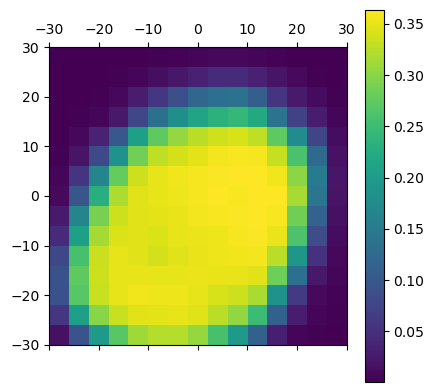

In [4]:
N_pts = 15
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 30
center_zero = [0,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2026-03-30 15:32:04,038 - INFO - z0: ((0, 0), 0.26737500000000003)
100%|██████████| 400/400 [03:29<00:00,  1.91it/s]
2026-03-30 15:35:33,268 - INFO - going home


0.27818750000000003
0.0005625000000000001


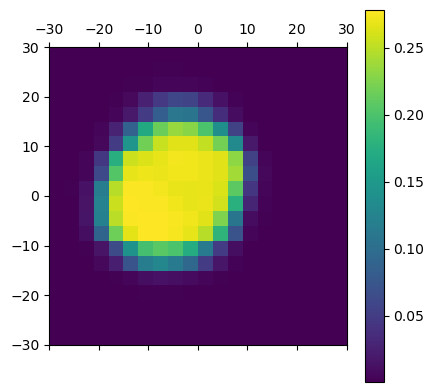

In [15]:
N_pts = 20
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [10,-20,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2026-01-28 10:58:56,004 - INFO - z0: ((0, 0), 0.314375)
100%|██████████| 400/400 [03:38<00:00,  1.83it/s]
2026-01-28 11:02:34,146 - INFO - going home


0.3246875
0.0005625000000000001


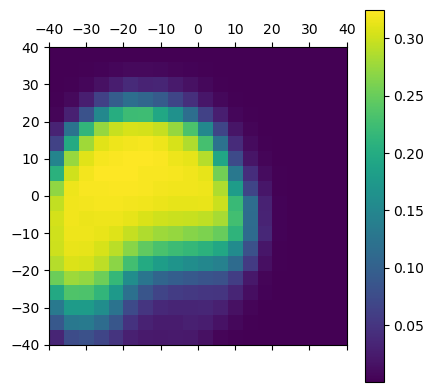

In [37]:
N_pts = 20
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 40
center_zero = [0,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2026-01-28 15:31:07,629 - INFO - z0: ((0, 0), 0.35875)
100%|██████████| 100/100 [00:59<00:00,  1.68it/s]
2026-01-28 15:32:07,114 - INFO - going home


0.36475
0.0003125


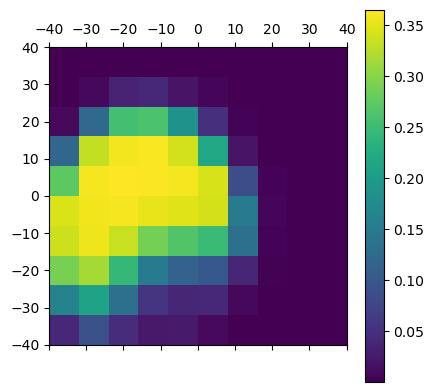

In [41]:
N_pts = 10
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 40
center_zero = [0,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2026-01-28 15:33:08,823 - INFO - z0: ((0, 0), 0.3170625)
100%|██████████| 625/625 [06:09<00:00,  1.69it/s]
2026-01-28 15:39:17,831 - INFO - going home


0.36793750000000003
0.0005


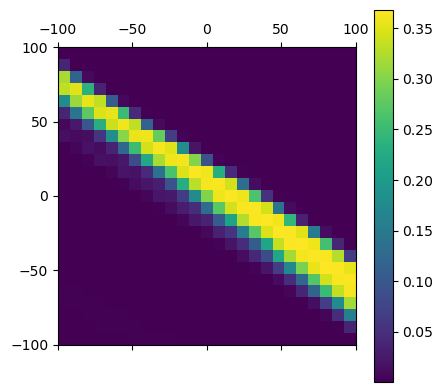

In [42]:
N_pts = 25
POS_MASK = B_Y_YDOT_MASK
SCAN_RANGE = 100
center_zero = [0,0,0,0,-10,-10,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2026-01-28 15:51:24,815 - INFO - z0: ((0, 0), 0.3469375)
100%|██████████| 100/100 [00:59<00:00,  1.67it/s]
2026-01-28 15:52:24,543 - INFO - going home


0.368625
0.000625


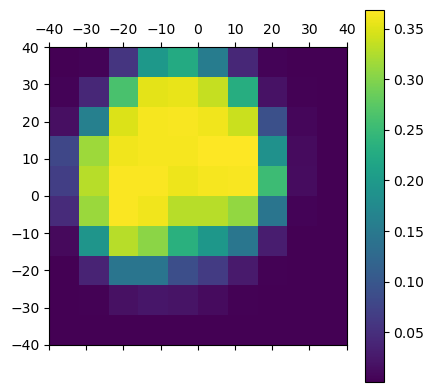

In [ ]:
N_pts = 10
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 40
center_zero = [0,0,0,0,-10,90,0,-70]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2026-01-28 15:54:54,810 - INFO - z0: ((0, 0), 0.3623125)
100%|██████████| 625/625 [06:10<00:00,  1.69it/s]
2026-01-28 16:01:05,251 - INFO - going home


0.368625
0.0005


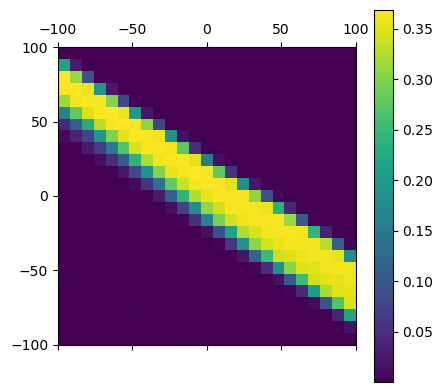

In [58]:
N_pts = 25
POS_MASK = B_Y_YDOT_MASK
SCAN_RANGE = 100
center_zero = [0,0,0,0,-15,95,0,-70]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2026-01-28 16:01:53,783 - INFO - z0: ((0, 0), 0.3535)
100%|██████████| 100/100 [00:59<00:00,  1.68it/s]
2026-01-28 16:02:53,270 - INFO - going home


0.36925
0.000625


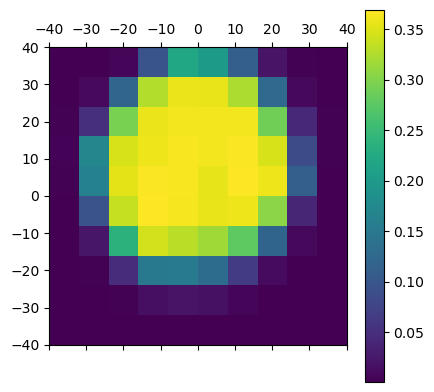

In [59]:
N_pts = 10
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 40
center_zero = [0,0,0,0,-15,195,0,-140]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2026-01-28 16:10:44,735 - INFO - z0: ((0, 0), 0.3594375)
100%|██████████| 400/400 [03:37<00:00,  1.84it/s]
2026-01-28 16:14:22,062 - INFO - going home


0.369625
0.000625


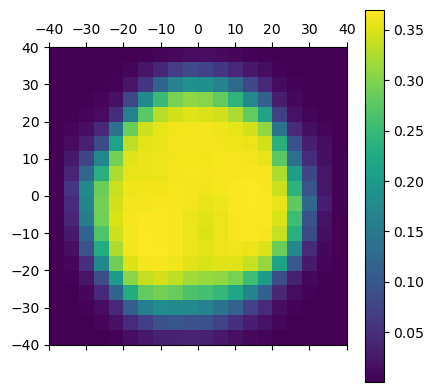

In [61]:
N_pts = 20
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 40
center_zero = [0,0,0,0,-15,205,0,-140]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2026-02-11 15:06:32,736 - INFO - z0: ((0, 0), 0.3456875)
100%|██████████| 400/400 [04:35<00:00,  1.45it/s]
2026-02-11 15:11:08,523 - INFO - going home


0.357125
0.0005625000000000001


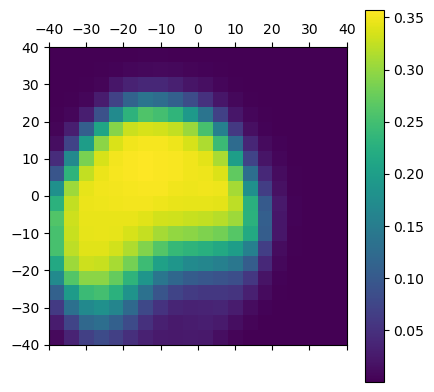

In [2]:
N_pts = 20
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 40
center_zero = [0, 0, 0, 0, 15.0, -205.0, 0.0, 140.0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

In [9]:
servos.set_angle([0,0,0,0,0,0,0,0])

In [5]:
servos.set_angle([-1.0, 34.0, 7.0, -29.0, 10.0, -20.0, 0.0, 0.0])

In [11]:
print(MCP3424_fiber.convert_and_read()/2*630)

0.17718750000000003


[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


2026-01-23 18:14:48,766 - INFO - z0: ((0, 0), 0.255125)
100%|██████████| 400/400 [03:36<00:00,  1.85it/s]
2026-01-23 18:18:25,026 - INFO - going home


0.3310625
0.0005


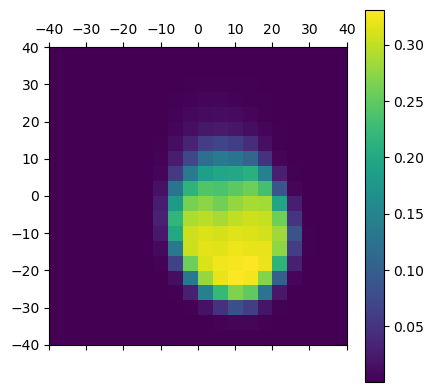

In [13]:
N_pts = 20
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 40
center_zero = [16.68235095879377, 30.366823678343597, 22.248020723861643, -26.732201202566937, 0.0, -20.0, 0.0, 0.0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2026-01-20 13:18:19,470 - INFO - z0: ((0, 0), 0.2664375)
100%|██████████| 400/400 [03:35<00:00,  1.86it/s]
2026-01-20 13:21:54,480 - INFO - going home


0.2725625
0.0005


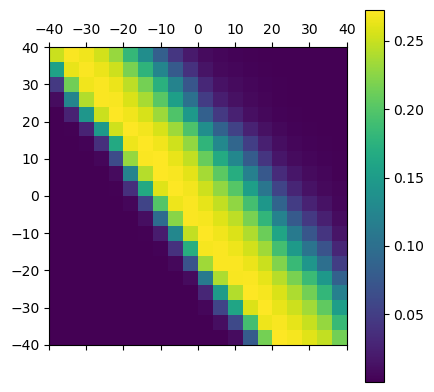

In [26]:
N_pts = 20
POS_MASK = A_Y_YDOT_MASK
SCAN_RANGE = 40
center_zero = [0,-10,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2026-02-19 16:45:44,978 - INFO - z0: ((0, 0), 0.0005625000000000001)
100%|██████████| 625/625 [06:06<00:00,  1.71it/s]
2026-02-19 16:51:51,282 - INFO - going home


0.112375
0.0005


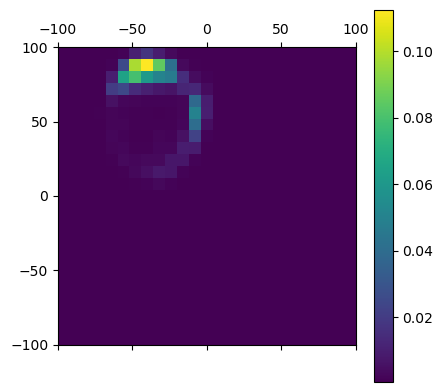

In [14]:
N_pts = 25
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 100
center_zero = [0,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2026-02-19 16:56:30,426 - INFO - z0: ((0, 0), 0.078125)
100%|██████████| 625/625 [06:06<00:00,  1.70it/s]
2026-02-19 17:02:37,248 - INFO - going home


0.1289375
0.0005


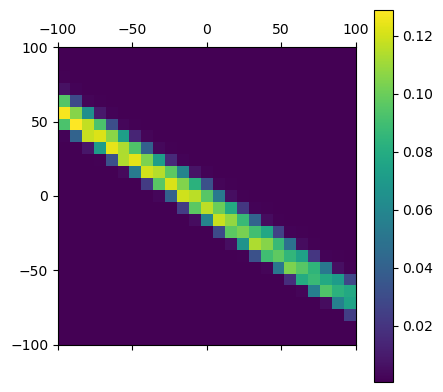

In [15]:
N_pts = 25
POS_MASK = B_X_XDOT_MASK
SCAN_RANGE = 100
center_zero = [0,0,0,0,-40,85,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2026-02-19 17:03:53,099 - INFO - z0: ((0, 0), 0.07425)
100%|██████████| 400/400 [04:08<00:00,  1.61it/s]
2026-02-19 17:08:01,590 - INFO - going home


0.1930625
0.0005


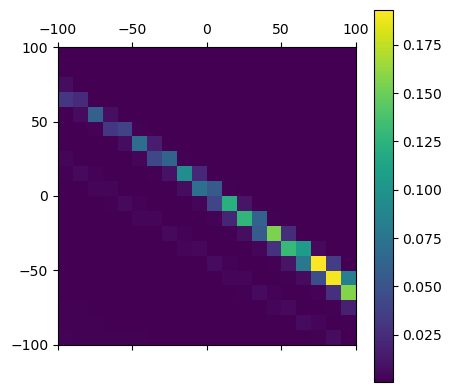

In [16]:
N_pts = 20
POS_MASK = B_Y_YDOT_MASK
SCAN_RANGE = 100
center_zero = [0,0,0,0,-40,85,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

In [6]:
B_XDOT_YDOT_MASK

[0, 0, 0, 0, 1, 1, 0, 0]

2025-10-30 13:02:00,983 - INFO - z0: ((0, 0), 2.0479375)
100%|██████████| 625/625 [05:42<00:00,  1.82it/s]
2025-10-30 13:07:43,903 - INFO - going home


2.0479375
0.000875


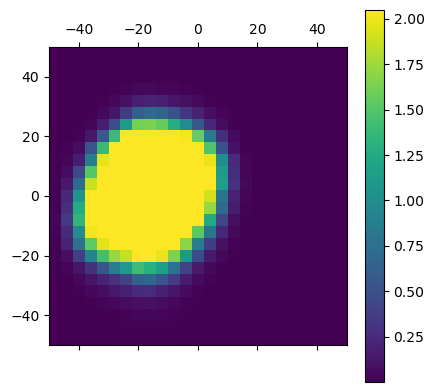

In [5]:
N_pts = 25
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 50
center_zero = [0,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-30 13:02:00,983 - INFO - z0: ((0, 0), 2.0479375)
100%|██████████| 625/625 [05:42<00:00,  1.82it/s]
2025-10-30 13:07:43,903 - INFO - going home


2.0479375
0.000875


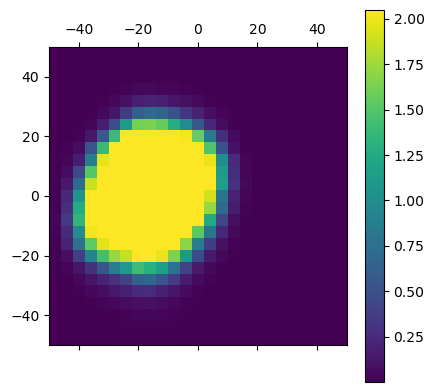

In [ ]:
N_pts = 25
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 50
center_zero = [0,0,0,0,0,150,0,-100]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-30 14:44:55,109 - INFO - z0: ((0, 0), 0.0116875)
100%|██████████| 625/625 [06:08<00:00,  1.70it/s]
2025-10-30 14:51:03,334 - INFO - going home


0.016375
0.0005


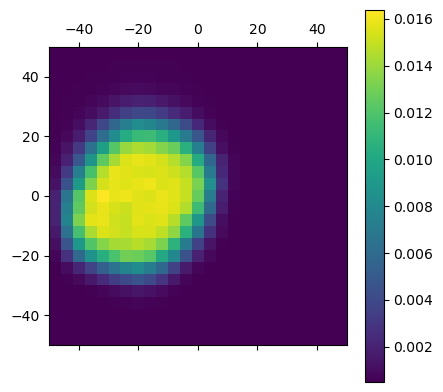

In [20]:
N_pts = 25
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 50
center_zero = [0,0,0,0,0,-150,0,100]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-30 17:10:04,982 - INFO - z0: ((0, 0), 0.1921875)
100%|██████████| 225/225 [02:00<00:00,  1.86it/s]
2025-10-30 17:12:05,973 - INFO - going home


0.19525
0.00075


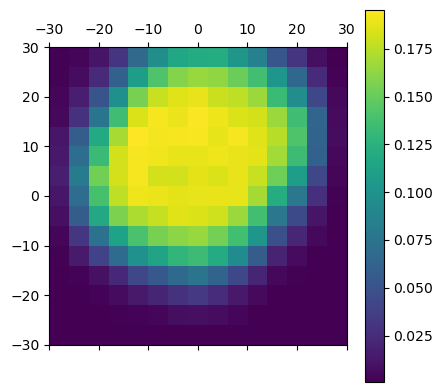

In [ ]:
N_pts = 15
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 30
center_zero = [0,0,0,0,-20,-100,0,200]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-30 17:25:51,070 - INFO - z0: ((0, 0), 0.0014375)
100%|██████████| 225/225 [02:12<00:00,  1.70it/s]
2025-10-30 17:28:03,183 - INFO - going home


0.194
0.0006875


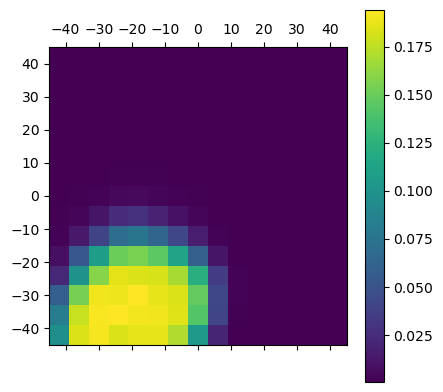

In [38]:
N_pts = 15
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 45
center_zero = [0,0,0,0,0,-140,0,300]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

In [38]:
servos.set_angle([-50,-80,0,0,0,0,0,0])
MCP3424_fiber.convert_and_read()/2*8.4

0.26565

In [9]:
servos.torques_enable()
servos.get_angle()

array([ 0.        ,  0.        , -0.08789062,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ])

2025-10-31 16:13:27,065 - INFO - z0: ((0, 0), 0.1000625)
100%|██████████| 400/400 [04:56<00:00,  1.35it/s]
2025-10-31 16:18:23,106 - INFO - going home


0.163625
0.0005625000000000001


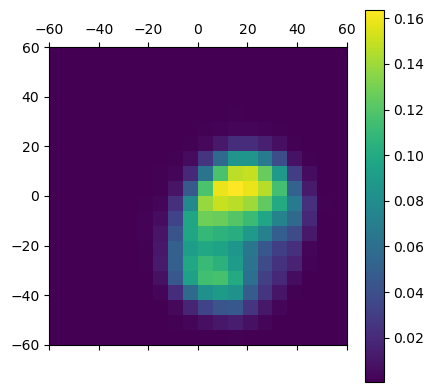

In [26]:
N_pts = 20
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 60
center_zero = [0,0,0,0,0,-300,0,200]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-31 16:19:22,512 - INFO - z0: ((0, 0), 0.1785625)
100%|██████████| 100/100 [01:13<00:00,  1.36it/s]
2025-10-31 16:20:36,125 - INFO - going home


0.19187500000000002
0.000625


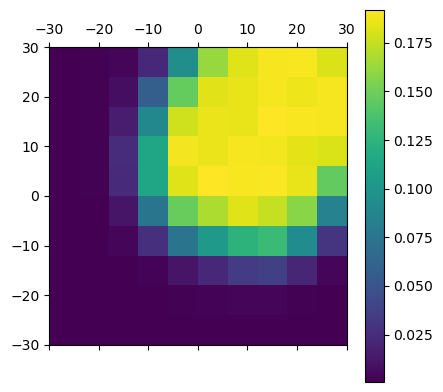

In [29]:
N_pts = 10
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 30
center_zero = [0,0,0,0,0,280,0,-200]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 10:53:22,978 - INFO - z0: ((0, 0), 0.2129375)
100%|██████████| 100/100 [00:56<00:00,  1.77it/s]
2025-11-03 10:54:19,496 - INFO - going home


0.26056250000000003
0.0008125000000000001


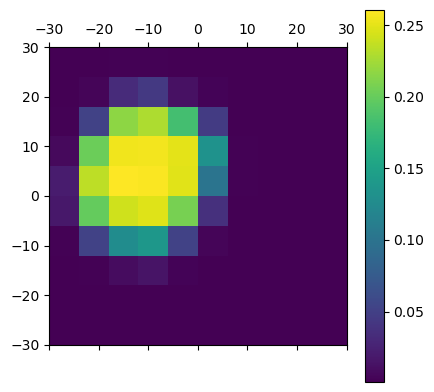

In [5]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 10:57:51,803 - INFO - z0: ((0, 0), 0.2073125)
100%|██████████| 100/100 [00:56<00:00,  1.77it/s]
2025-11-03 10:58:48,373 - INFO - going home


0.254375
0.0008125000000000001


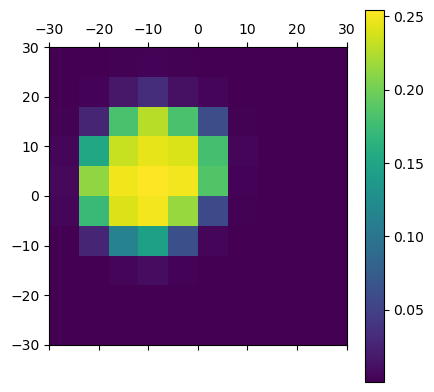

In [13]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,-50,0,70,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 14:04:18,851 - INFO - z0: ((0, 0), 0.174375)
100%|██████████| 100/100 [00:56<00:00,  1.78it/s]
2025-11-03 14:05:15,131 - INFO - going home


0.2371875
0.0008125000000000001


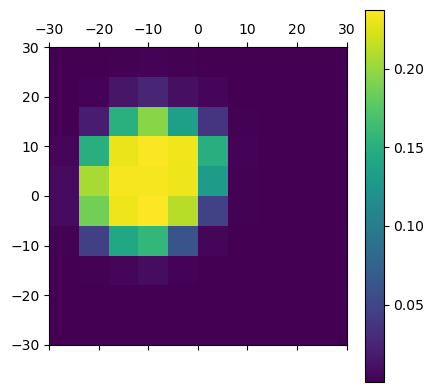

In [15]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,-100,0,140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 14:05:38,807 - INFO - z0: ((0, 0), 0.0618125)
100%|██████████| 100/100 [00:56<00:00,  1.77it/s]
2025-11-03 14:06:35,241 - INFO - going home


0.2256875
0.0008125000000000001


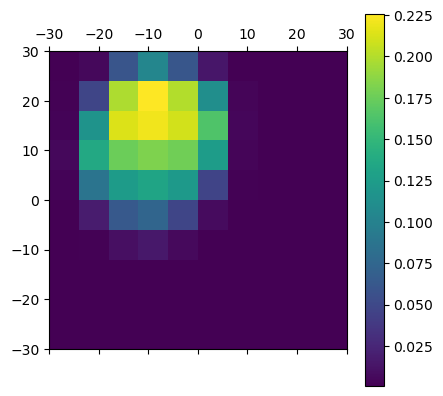

In [16]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,100,0,-140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 14:55:50,858 - INFO - z0: ((0, 0), 0.003375)
100%|██████████| 100/100 [00:56<00:00,  1.77it/s]
2025-11-03 14:56:47,429 - INFO - going home


0.10725
0.00075


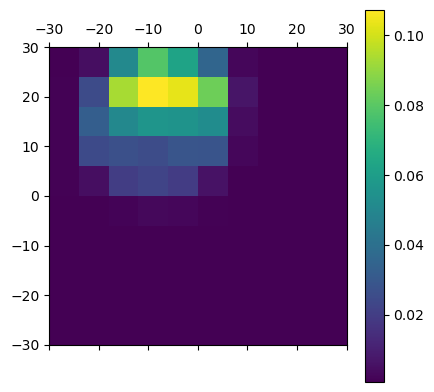

In [43]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,100,0,-140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 15:05:16,819 - INFO - z0: ((0, 0), 0.06293750000000001)
100%|██████████| 100/100 [00:56<00:00,  1.77it/s]
2025-11-03 15:06:13,365 - INFO - going home


0.2318125
0.0008125000000000001


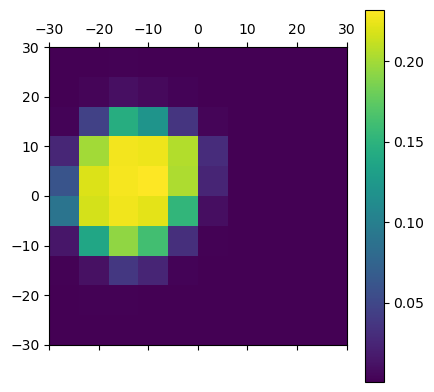

In [54]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,-100,0,140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 15:28:24,386 - INFO - z0: ((0, 0), 0.0138125)
100%|██████████| 100/100 [00:56<00:00,  1.78it/s]
2025-11-03 15:29:20,607 - INFO - going home


0.215375
0.0008125000000000001


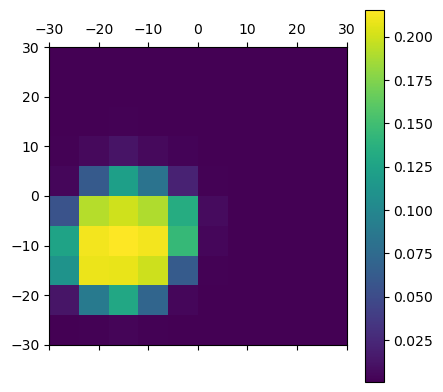

In [66]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,-100,0,140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 15:36:35,627 - INFO - z0: ((0, 0), 0.0043125)
100%|██████████| 100/100 [00:56<00:00,  1.78it/s]
2025-11-03 15:37:31,805 - INFO - going home


0.2005
0.0008125000000000001


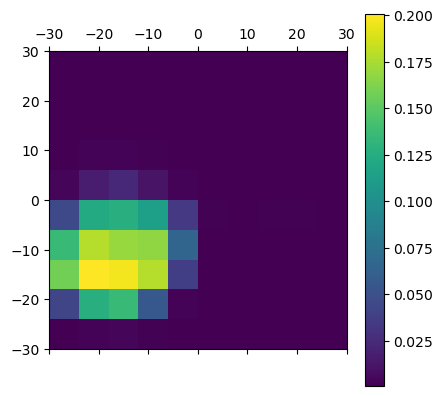

In [71]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,-100,0,140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 15:43:00,285 - INFO - z0: ((0, 0), 0.0013125)
100%|██████████| 100/100 [00:56<00:00,  1.78it/s]
2025-11-03 15:43:56,435 - INFO - going home


0.14625
0.0008125000000000001


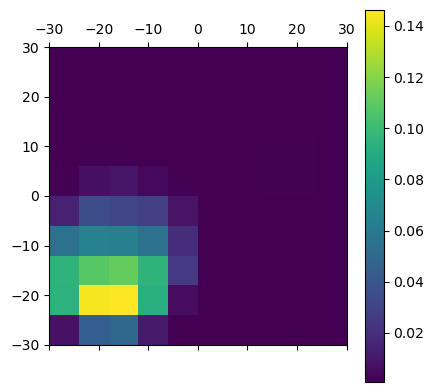

In [78]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,-100,0,140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 15:53:27,433 - INFO - z0: ((0, 0), 0.0011250000000000001)
100%|██████████| 100/100 [00:56<00:00,  1.78it/s]
2025-11-03 15:54:23,699 - INFO - going home


0.0490625
0.00075


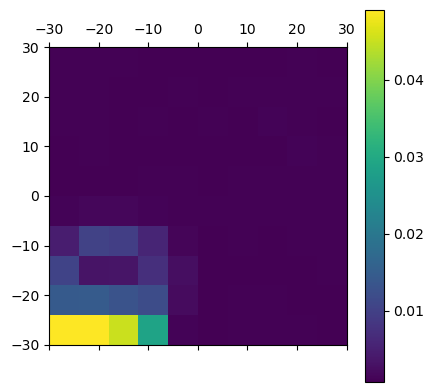

In [84]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,-100,0,140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 15:56:56,149 - INFO - z0: ((0, 0), 0.0465)
100%|██████████| 100/100 [00:56<00:00,  1.77it/s]
2025-11-03 15:57:52,687 - INFO - going home


0.064125
0.00075


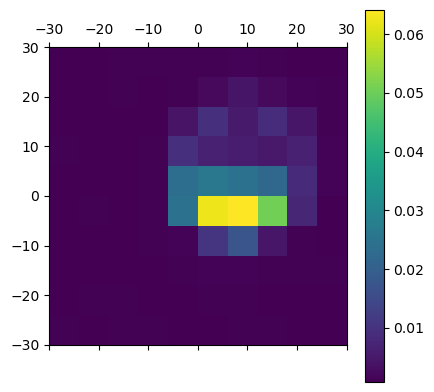

In [85]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [-30,-130,0,140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 16:20:42,199 - INFO - z0: ((0, 0), 0.19625)
100%|██████████| 100/100 [00:56<00:00,  1.76it/s]
2025-11-03 16:21:38,888 - INFO - going home


0.2360625
0.0005


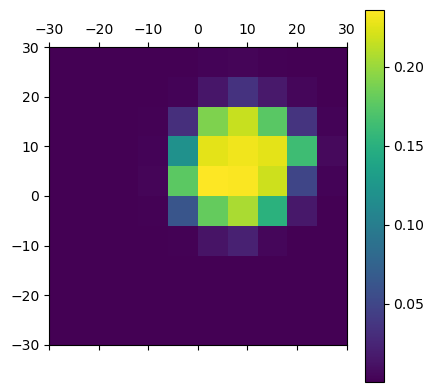

In [5]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [-30,-130,0,140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 16:24:20,661 - INFO - z0: ((0, 0), 0.1686875)
100%|██████████| 100/100 [00:56<00:00,  1.78it/s]
2025-11-03 16:25:16,938 - INFO - going home


0.2249375
0.0005


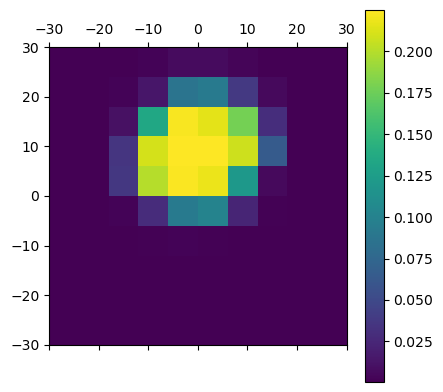

In [11]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,-100,0,140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 16:53:40,036 - INFO - z0: ((0, 0), 0.1911875)
100%|██████████| 100/100 [00:56<00:00,  1.77it/s]
2025-11-03 16:54:36,668 - INFO - going home


0.22275
0.0005


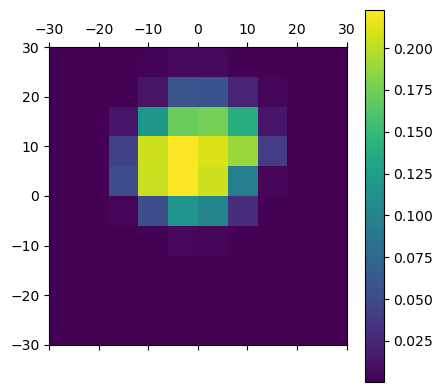

In [17]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,-100,0,140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 17:04:11,756 - INFO - z0: ((0, 0), 0.171)
100%|██████████| 100/100 [00:56<00:00,  1.78it/s]
2025-11-03 17:05:07,896 - INFO - going home


0.198875
0.0005


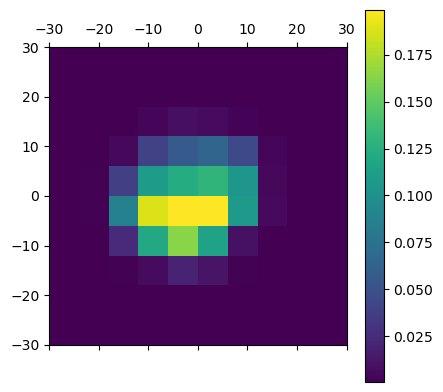

In [24]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,-100,0,140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 17:11:30,873 - INFO - z0: ((0, 0), 0.0525625)
100%|██████████| 100/100 [00:56<00:00,  1.78it/s]
2025-11-03 17:12:27,151 - INFO - going home


0.1448125
0.0005


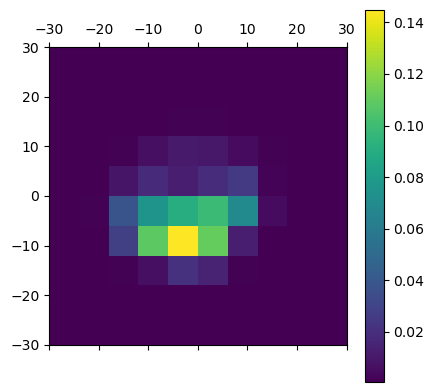

In [28]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,-100,0,140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 17:28:40,889 - INFO - z0: ((0, 0), 0.0081875)
100%|██████████| 100/100 [00:56<00:00,  1.78it/s]
2025-11-03 17:29:37,080 - INFO - going home


0.0395
0.0005


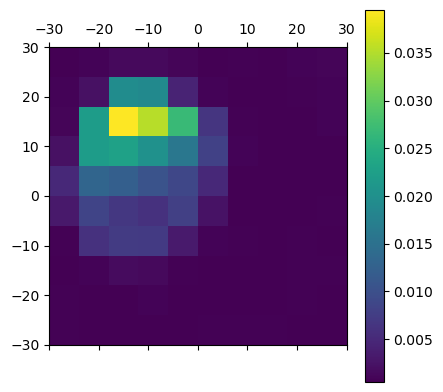

In [69]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 17:33:09,387 - INFO - z0: ((0, 0), 0.134625)
100%|██████████| 100/100 [00:56<00:00,  1.78it/s]
2025-11-03 17:34:05,698 - INFO - going home


0.2370625
0.0005


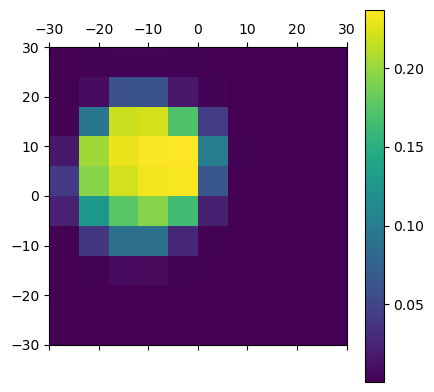

In [71]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 17:50:32,264 - INFO - z0: ((0, 0), 0.047)
100%|██████████| 100/100 [00:56<00:00,  1.77it/s]
2025-11-03 17:51:28,652 - INFO - going home


0.213625
0.0005


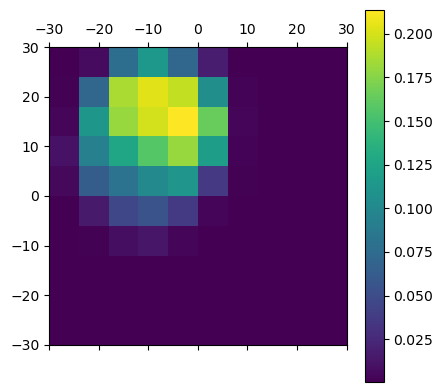

In [73]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,100,0,-140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 18:18:10,006 - INFO - z0: ((0, 0), 0.0030625)
100%|██████████| 100/100 [00:56<00:00,  1.77it/s]
2025-11-03 18:19:06,373 - INFO - going home


0.12625
0.0005


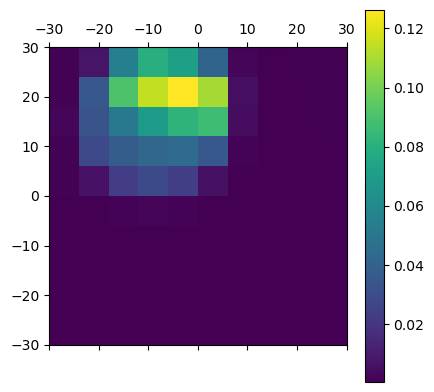

In [77]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,100,0,-140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 18:29:43,437 - INFO - z0: ((0, 0), 0.0078125)
100%|██████████| 100/100 [00:56<00:00,  1.77it/s]
2025-11-03 18:30:39,903 - INFO - going home


0.2255
0.0005


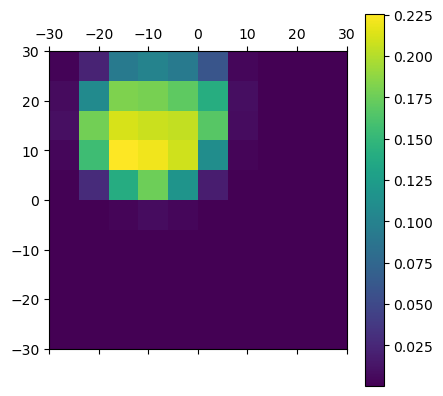

In [6]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,100,0,-140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 18:36:47,173 - INFO - z0: ((0, 0), 0.036875)
100%|██████████| 100/100 [00:56<00:00,  1.77it/s]
2025-11-03 18:37:43,596 - INFO - going home


0.169625
0.0005


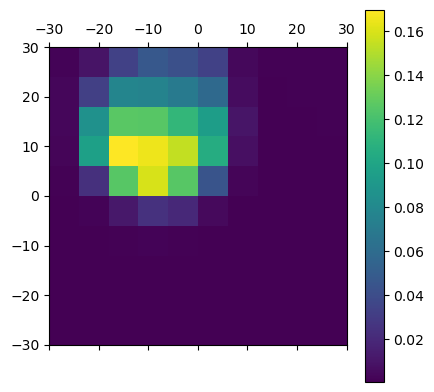

In [12]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,100,0,-140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 18:46:26,937 - INFO - z0: ((0, 0), 0.012625)
100%|██████████| 100/100 [00:56<00:00,  1.78it/s]
2025-11-03 18:47:23,036 - INFO - going home


0.11875000000000001
0.0005


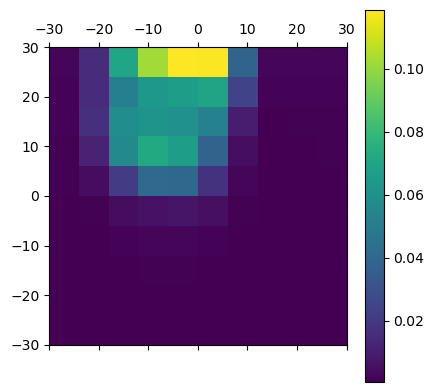

In [17]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,100,0,-140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-03 18:54:02,997 - INFO - z0: ((0, 0), 0.116625)
100%|██████████| 100/100 [00:56<00:00,  1.78it/s]
2025-11-03 18:54:59,207 - INFO - going home


0.1386875
0.000625


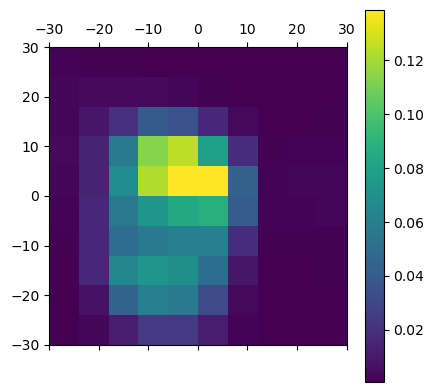

In [23]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [0,130,0,-140,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-04 11:26:35,416 - INFO - z0: ((0, 0), 0.25425000000000003)
100%|██████████| 100/100 [00:53<00:00,  1.87it/s]
2025-11-04 11:27:28,987 - INFO - going home


0.2510625
0.0006875


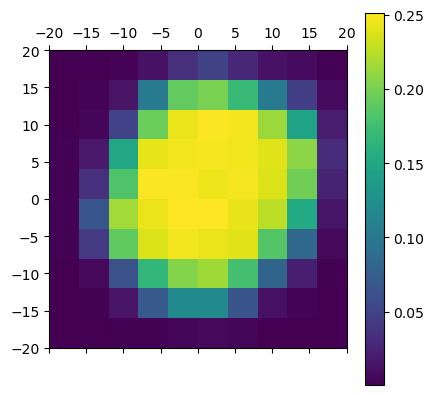

In [37]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 20
center_zero = [-15,5,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-05 18:27:44,660 - INFO - z0: ((0, 0), 0.198875)
100%|██████████| 100/100 [00:53<00:00,  1.87it/s]
2025-11-05 18:28:38,153 - INFO - going home


0.199375
0.0005625000000000001


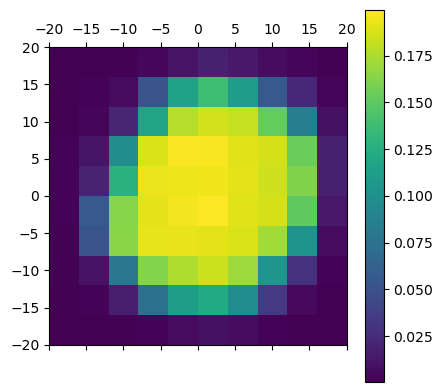

In [41]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 20
center_zero = [0,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-05 18:29:55,848 - INFO - z0: ((0, 0), 0.205625)
100%|██████████| 100/100 [00:53<00:00,  1.86it/s]
2025-11-05 18:30:49,529 - INFO - going home


0.2058125
0.000625


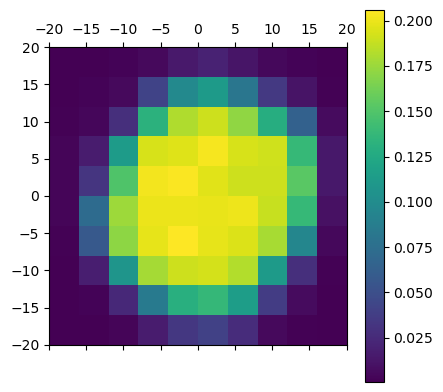

In [43]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 20
center_zero = [0, 100, 0, -140, 0, 0, 0, 0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-05 18:55:01,772 - INFO - z0: ((0, 0), 0.2353125)
100%|██████████| 100/100 [00:53<00:00,  1.88it/s]
2025-11-05 18:55:55,102 - INFO - going home


0.2480625
0.0006875


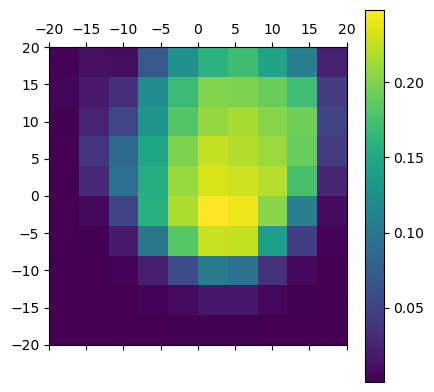

In [50]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 20
center_zero = [0, 100, 0, -140, 0, 0, 0, 0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-06 11:13:23,706 - INFO - z0: ((0, 0), 0.1915)
100%|██████████| 100/100 [00:53<00:00,  1.87it/s]
2025-11-06 11:14:17,098 - INFO - going home


0.2060625
0.0005625000000000001


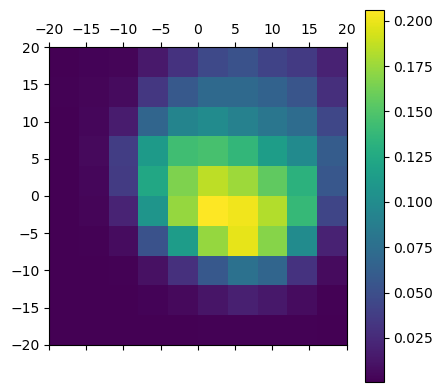

In [24]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 20
center_zero = [0, 0, 0, 0, 0, 0, 0, 0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-07 20:05:45,033 - INFO - z0: ((0, 0), 0.0935625)
100%|██████████| 100/100 [00:53<00:00,  1.87it/s]
2025-11-07 20:06:38,421 - INFO - going home


0.105
0.0005625000000000001


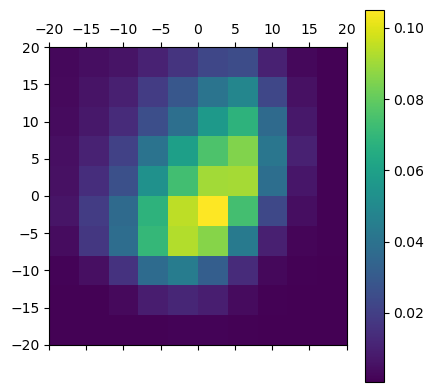

In [3]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 20
center_zero = [0, 0, 0, 0, 0, 0, 0, 0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-06 15:57:52,220 - INFO - z0: ((0, 0), 0.1476875)
100%|██████████| 225/225 [01:59<00:00,  1.88it/s]
2025-11-06 15:59:51,714 - INFO - going home


0.1583125
0.0008125000000000001


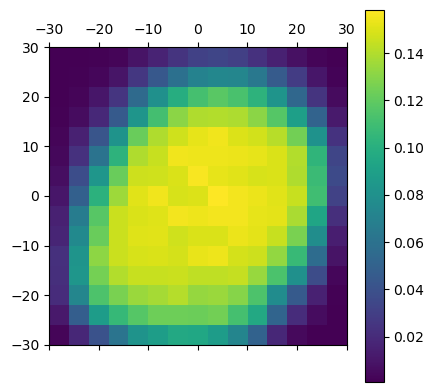

In [11]:
N_pts = 15
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 30
center_zero = [0,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-07 14:55:29,479 - INFO - z0: ((0, 0), 0.0009375)
100%|██████████| 225/225 [01:59<00:00,  1.89it/s]
2025-11-07 14:57:28,802 - INFO - going home


0.0010625
0.0005


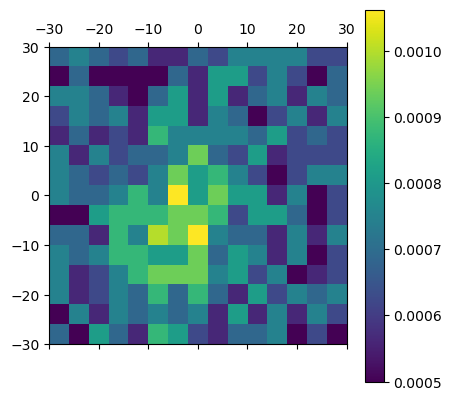

In [77]:
N_pts = 15
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 30
center_zero = [0,0,0,0,0,-100,0,70]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-07 19:45:22,900 - INFO - z0: ((0, 0), 0.0076875)
100%|██████████| 400/400 [04:54<00:00,  1.36it/s]
2025-11-07 19:50:17,629 - INFO - going home


0.0118125
0.0016250000000000001


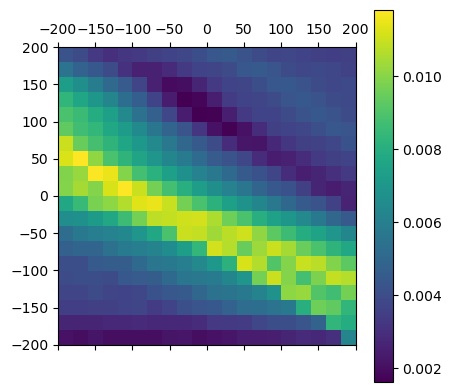

In [10]:
N_pts = 20
POS_MASK = B_X_XDOT_MASK
SCAN_RANGE = 200
center_zero = [0,0,0,0,-100,0,75,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-12 17:20:05,700 - INFO - z0: ((0, 0), 0.2904375)
100%|██████████| 100/100 [01:12<00:00,  1.37it/s]
2025-11-12 17:21:18,598 - INFO - going home


0.315125
0.0029375


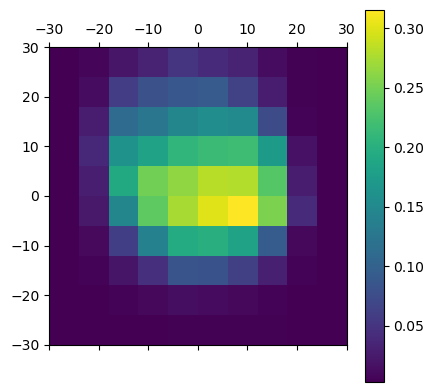

In [11]:
N_pts = 10
POS_MASK = A_XDOT_YDOT_MASK
SCAN_RANGE = 30
center_zero = [0,200,-15,-280,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

In [17]:
servos.torques_disable()
servos.get_angle()

array([0., 0., 0., 0., 0., 0., 0., 0.])

2025-11-12 13:15:50,519 - INFO - z0: ((0, 0), 0.22693750000000001)
100%|██████████| 100/100 [01:10<00:00,  1.42it/s]
2025-11-12 13:17:01,159 - INFO - going home


0.228
0.0005


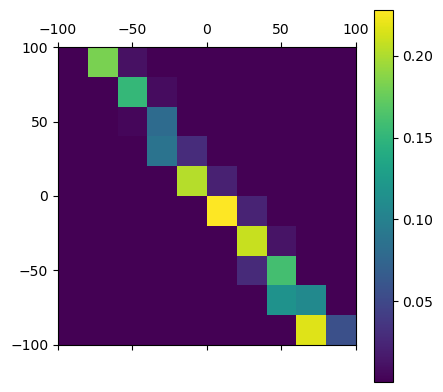

In [104]:
N_pts = 10
POS_MASK = A_Y_YDOT_MASK
SCAN_RANGE = 100
center_zero = [0,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-12 13:03:44,393 - INFO - z0: ((0, 0), 0.2390625)
100%|██████████| 100/100 [01:10<00:00,  1.41it/s]
2025-11-12 13:04:55,383 - INFO - going home


0.236375
0.0005


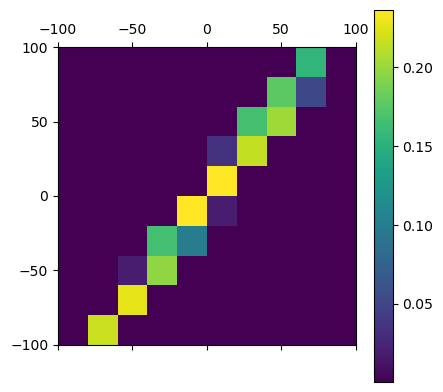

In [97]:
N_pts = 10
POS_MASK = A_X_XDOT_MASK
SCAN_RANGE = 100
center_zero = [0,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-12 13:00:17,468 - INFO - z0: ((0, 0), 0.22868750000000002)
100%|██████████| 100/100 [00:59<00:00,  1.69it/s]
2025-11-12 13:01:16,502 - INFO - going home


0.21975
0.0005


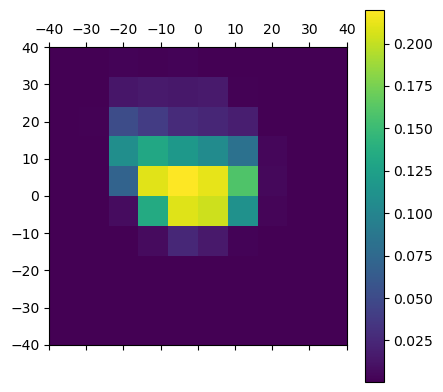

In [96]:
N_pts = 10
POS_MASK = A_XDOT_YDOT_MASK
SCAN_RANGE = 40
center_zero = [0,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-31 11:29:29,199 - INFO - z0: ((0, 0), 0.00075)
100%|██████████| 625/625 [07:35<00:00,  1.37it/s]
2025-10-31 11:37:04,272 - INFO - going home


0.1938125
0.0006875


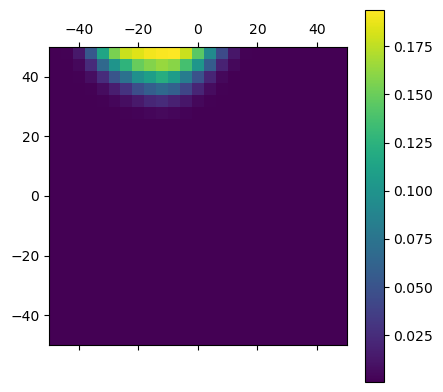

In [27]:
N_pts = 25
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 50
center_zero = [0,0,0,0,0,-300,0,200]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-31 11:44:29,092 - INFO - z0: ((0, 0), 0.1478125)
100%|██████████| 400/400 [04:52<00:00,  1.37it/s]
2025-10-31 11:49:21,168 - INFO - going home


0.21375
0.0006875


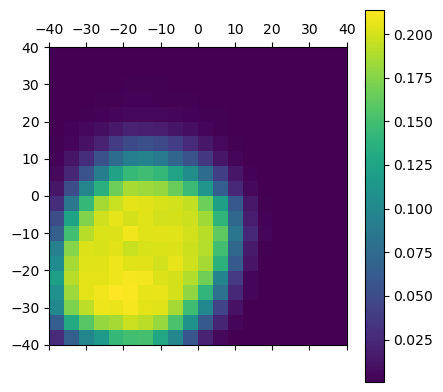

In [33]:
N_pts = 20
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 40
center_zero = [0,0,0,0,0,-280,0,200]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-31 11:55:53,406 - INFO - z0: ((0, 0), 0.001)
100%|██████████| 400/400 [04:52<00:00,  1.37it/s]
2025-10-31 12:00:46,352 - INFO - going home


0.213
0.0006875


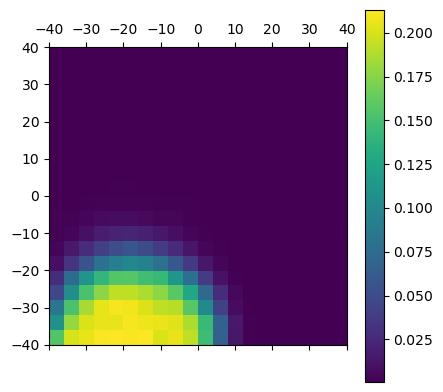

In [36]:
N_pts = 20
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 40
center_zero = [0,0,0,0,0,-280,0,200]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

In [49]:
servos.set_angle([0,0,0,0,0,0,0,0])
MCP3424_fiber.convert_and_read()/2*8.4

0.38325

In [53]:
servos.set_angle([0,0,0,0,-20,-340,0,200])

In [2]:
servos.torques_enable()

2025-10-31 13:36:57,810 - INFO - z0: ((0, 0), 0.0011250000000000001)
100%|██████████| 100/100 [00:54<00:00,  1.83it/s]
2025-10-31 13:37:52,575 - INFO - going home


0.2038125
0.00075


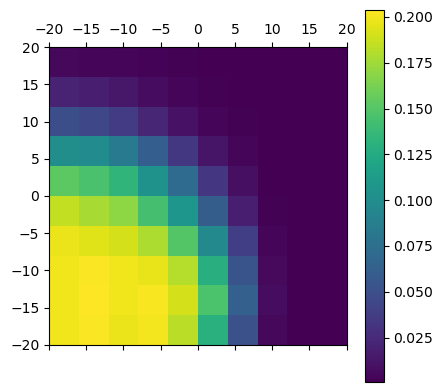

In [6]:
N_pts = 10
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 20
center_zero = [0,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-31 11:29:29,199 - INFO - z0: ((0, 0), 0.00075)
100%|██████████| 625/625 [07:35<00:00,  1.37it/s]
2025-10-31 11:37:04,272 - INFO - going home


0.1938125
0.0006875


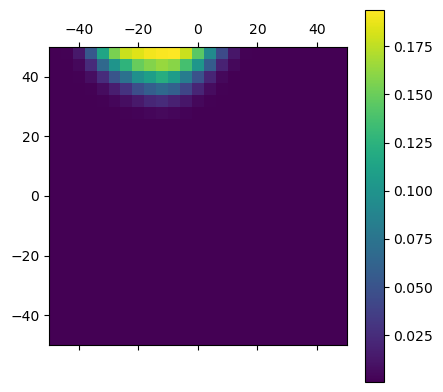

In [ ]:
N_pts = 25
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 50
center_zero = [0,0,0,0,0,-300,0,200]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

In [18]:
servos.set_angle([0,0,0,0,-20,-150,0,100])

In [22]:
# print(servos.get_angle())
MCP3424_fiber.convert_and_read()/2*84

0.5145000000000001

2025-10-17 17:14:11,951 - INFO - z0: ((0, 0), 0.209625)
100%|██████████| 100/100 [00:57<00:00,  1.74it/s]
2025-10-17 17:15:09,407 - INFO - going home


0.2083125
0.0005625000000000001


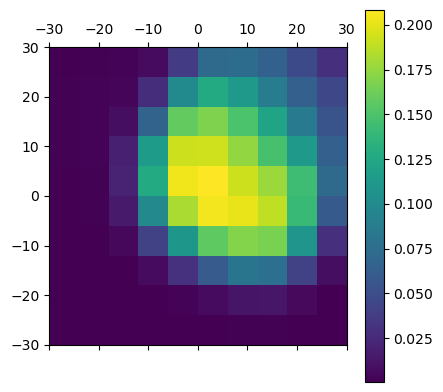

In [81]:
N_pts = 10
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 30
center_zero = [0,0,0,0,-5,150,0,-100]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

In [58]:
servos.home()

2025-11-24 13:41:33,782 - INFO - going home


In [62]:
servos.set_zero()

2025-11-24 13:44:55,909 - INFO - Setting Zero
2025-11-24 13:44:55,921 - INFO - Servo 1x: SCServo zero set!
2025-11-24 13:44:55,933 - INFO - Servo 1y: SCServo zero set!
2025-11-24 13:44:55,942 - INFO - Servo 2x: SCServo zero set!
2025-11-24 13:44:55,951 - INFO - Servo 2y: SCServo zero set!
2025-11-24 13:44:55,960 - INFO - Servo 3x: SCServo zero set!
2025-11-24 13:44:55,970 - INFO - Servo 3y: SCServo zero set!
2025-11-24 13:44:55,980 - INFO - Servo 4x: SCServo zero set!
2025-11-24 13:44:55,989 - INFO - Servo 4y: SCServo zero set!


In [38]:
servos.set_angle([0, 0, 0, 0, -14, -2, -23, 22])

In [55]:
print(MCP3424_fiber.convert_and_read()/2*120)

47.418749999999996


In [57]:
servos.torques_enable()

In [59]:
print(servos.get_angle().tolist())
# servos.torques_enable()

[-0.087890625, -24.43359375, -0.17578125, 25.927734375, 0.0, 0.0, 0.0, 0.0]


2025-11-24 11:53:40,399 - INFO - z0: ((0, 0), 0.27725)
100%|██████████| 225/225 [01:59<00:00,  1.89it/s]
2025-11-24 11:55:39,486 - INFO - going home


0.3614375
0.0006875


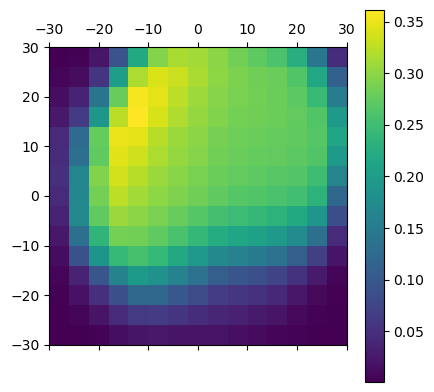

In [29]:
N_pts = 15
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 30
center_zero = [0, 0, 0, 0, -14, -2, -23, 22]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-17 17:03:53,060 - INFO - z0: ((0, 0), 0.0009375)
100%|██████████| 400/400 [04:11<00:00,  1.59it/s]
2025-11-17 17:08:04,431 - INFO - going home


0.0031875000000000002
0.0013125


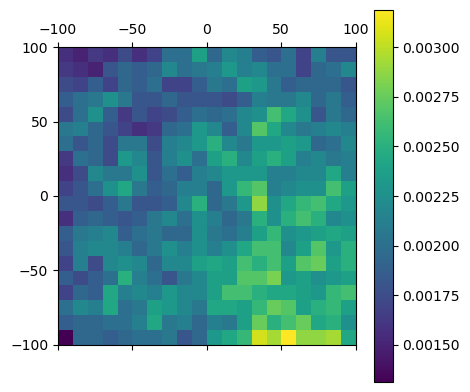

In [7]:
N_pts = 20
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 100
center_zero = [0,0,0,0,100,-100,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-17 17:09:02,594 - INFO - z0: ((0, 0), 0.00275)
100%|██████████| 400/400 [04:39<00:00,  1.43it/s]
2025-11-17 17:13:42,436 - INFO - going home


0.0036875000000000002
0.0018125


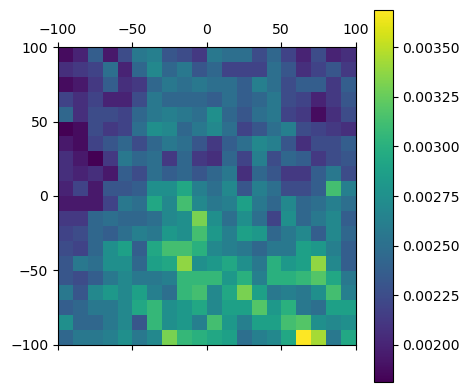

In [ ]:
N_pts = 20
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 100
center_zero = [0,0,0,0,170,-100,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-17 17:16:01,878 - INFO - z0: ((0, 0), 0.0023125)
100%|██████████| 3600/3600 [40:12<00:00,  1.49it/s]
2025-11-17 17:56:14,259 - INFO - going home


0.0726875
0.000875


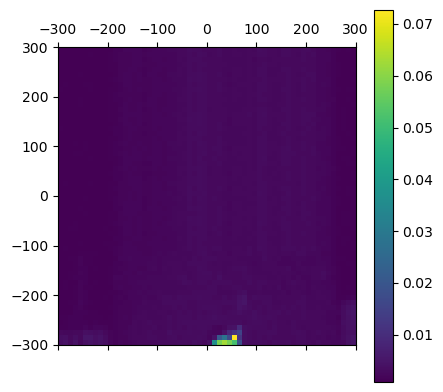

In [9]:
N_pts = 60
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 300
center_zero = [0,0,0,0,170,-100,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-17 18:24:53,151 - INFO - z0: ((0, 0), 0.002)
100%|██████████| 3600/3600 [41:50<00:00,  1.43it/s]
2025-11-17 19:06:44,131 - INFO - going home


0.022625
0.0006875


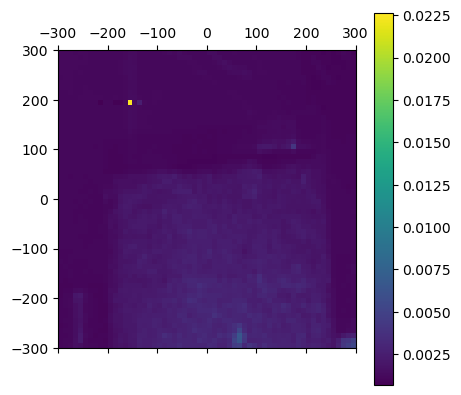

In [30]:
N_pts = 60
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 300
center_zero = [0,0,0,0,170,-200,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-17 19:19:29,531 - INFO - z0: ((0, 0), 0.002875)
 17%|█▋        | 617/3600 [07:59<35:05,  1.42it/s]2025-11-17 19:27:29,858 - INFO - [TxRxResult] There is no status packet!
2025-11-17 19:27:29,859 - ERROR - [ID:005] groupSyncRead getdata failed
100%|██████████| 3600/3600 [44:46<00:00,  1.34it/s]
2025-11-17 20:04:16,179 - INFO - going home


0.18675
0.0009375


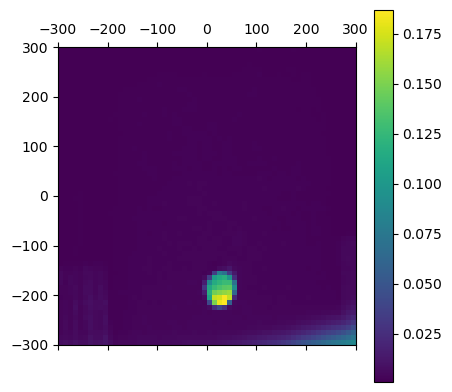

In [2]:
N_pts = 60
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 300
center_zero = [0,0,0,0,170,-400,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

In [13]:
servos.get_angle()

array([ 0.        , -0.08789062,  0.        ,  0.        , -0.08789062,
       -0.08789062,  0.        , -0.08789062])

In [8]:
from IPython.display import clear_output
import os
while 1:
    print(MCP3424_fiber.convert_and_read()/2*120)
    clear_output(wait=True)
    time.sleep(0.5)

KeyboardInterrupt: 

In [48]:
print(MCP3424_fiber.convert_and_read()/2*120)

50.61


2025-11-18 11:42:58,845 - INFO - z0: ((0, 0), 0.264375)
100%|██████████| 225/225 [02:05<00:00,  1.79it/s]
2025-11-18 11:45:04,663 - INFO - going home


0.277125
0.0005625000000000001


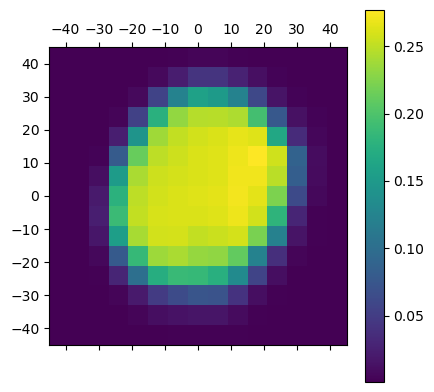

In [17]:
N_pts = 15
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 45
center_zero = [0,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

In [52]:
servos.set_angle([0,75,10,-100,0,0,0,0])

2025-11-18 15:56:46,897 - INFO - z0: ((0, 0), 0.87525)
100%|██████████| 400/400 [04:06<00:00,  1.62it/s]
2025-11-18 16:00:53,282 - INFO - going home


0.901625
0.0019375


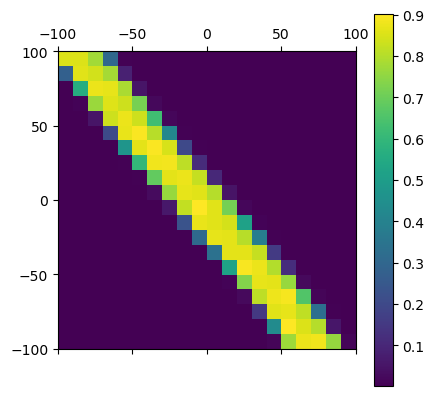

In [36]:
N_pts = 20
POS_MASK = A_Y_YDOT_MASK
SCAN_RANGE = 100
center_zero = [0,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-18 11:47:31,137 - INFO - z0: ((0, 0), 0.2649375)
100%|██████████| 400/400 [04:07<00:00,  1.61it/s]
2025-11-18 11:51:38,983 - INFO - going home


0.26887500000000003
0.0005


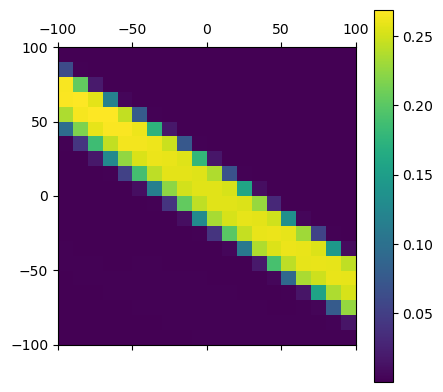

In [18]:
N_pts = 20
POS_MASK = B_Y_YDOT_MASK
SCAN_RANGE = 100
center_zero = [0,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-18 11:52:12,959 - INFO - z0: ((0, 0), 0.2664375)
100%|██████████| 400/400 [04:05<00:00,  1.63it/s]
2025-11-18 11:56:18,078 - INFO - going home


0.275125
0.0005


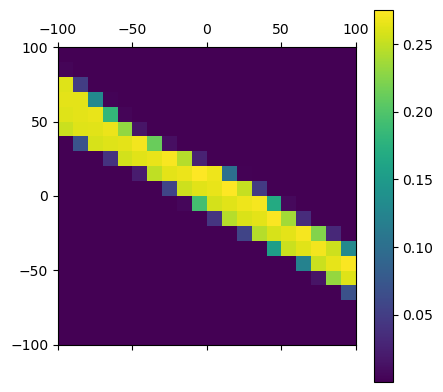

In [19]:
N_pts = 20
POS_MASK = B_X_XDOT_MASK
SCAN_RANGE = 100
center_zero = [0,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-11-17 15:10:00,830 - INFO - z0: ((0, 0), 0.007875)
100%|██████████| 400/400 [04:47<00:00,  1.39it/s]
2025-11-17 15:14:47,962 - INFO - going home


0.014625
0.001


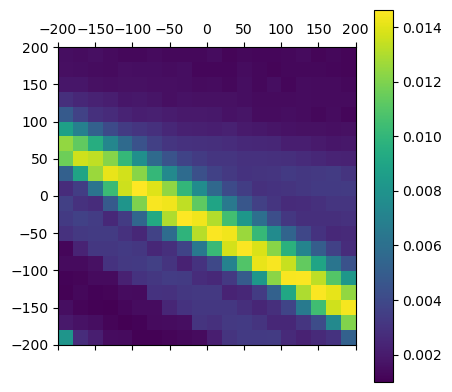

In [50]:
N_pts = 20
POS_MASK = B_Y_YDOT_MASK
SCAN_RANGE = 200
center_zero = [0,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-20 18:48:56,081 - INFO - z0: ((0, 0), 0.209)
100%|██████████| 100/100 [00:57<00:00,  1.73it/s]
2025-10-20 18:49:53,840 - INFO - going home


0.2054375
0.000875


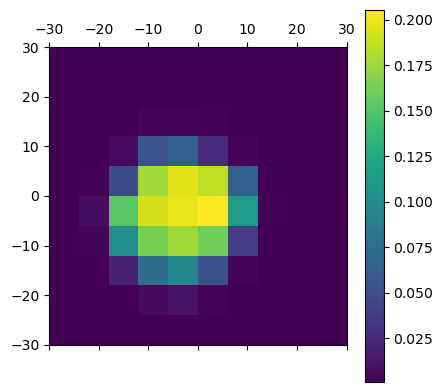

In [7]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
cf = lambda para: callback_func(para,pos_mask=POS_MASK)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-21 10:57:20,484 - INFO - z0: ((0, 0), 0.078125)
100%|██████████| 100/100 [00:57<00:00,  1.75it/s]
2025-10-21 10:58:17,715 - INFO - going home


0.2048125
0.000875


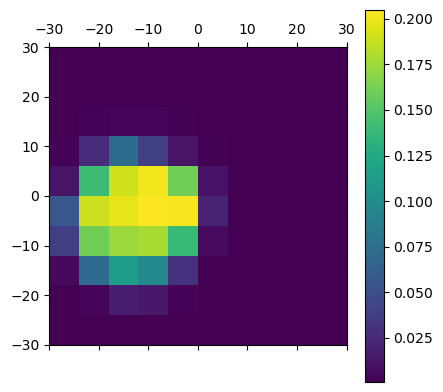

In [11]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 30
center_zero = [10,0,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-20 19:15:51,074 - INFO - z0: ((0, 0), 0.2005)
100%|██████████| 100/100 [00:56<00:00,  1.76it/s]
2025-10-20 19:16:47,913 - INFO - going home


0.20400000000000001
0.000875


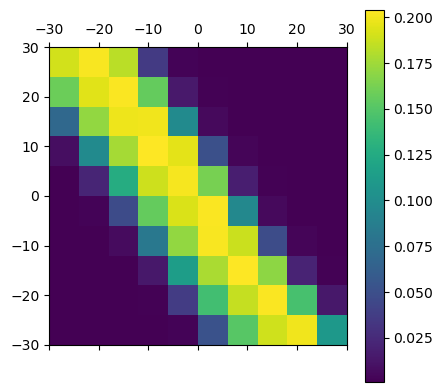

In [8]:
N_pts = 10
POS_MASK = A_Y_YDOT_MASK
SCAN_RANGE = 30
cf = lambda para: callback_func(para,pos_mask=POS_MASK)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-21 13:14:25,235 - INFO - z0: ((0, 0), 0.0016250000000000001)
100%|██████████| 900/900 [08:27<00:00,  1.77it/s]
2025-10-21 13:22:52,475 - INFO - going home


0.006875
0.000875


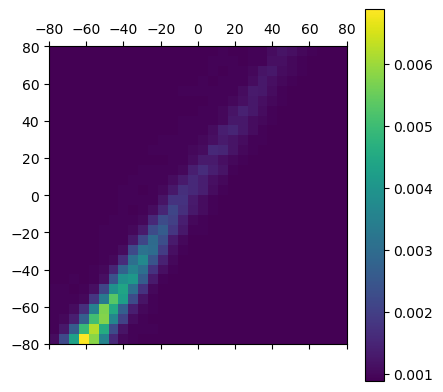

In [14]:
N_pts = 30
POS_MASK = A_X_XDOT_MASK
SCAN_RANGE = 80
center_zero = [0,20,0,0,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-22 18:56:04,602 - INFO - z0: ((0, 0), 0.000875)
100%|██████████| 625/625 [05:37<00:00,  1.85it/s]
2025-10-22 19:01:42,606 - INFO - going home


0.1896875
0.000875


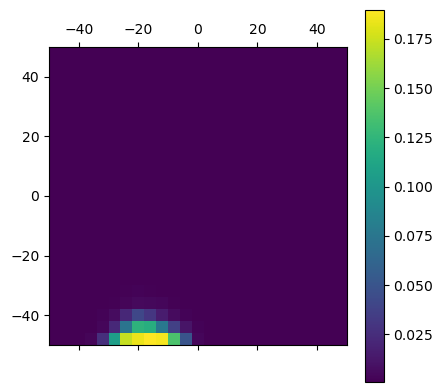

In [18]:
N_pts = 25
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 50
center_zero = [0,0,-20,72,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-23 16:40:58,973 - INFO - z0: ((0, 0), 0.000875)
100%|██████████| 100/100 [01:01<00:00,  1.61it/s]
2025-10-23 16:42:00,940 - INFO - going home


0.1751875
0.000875


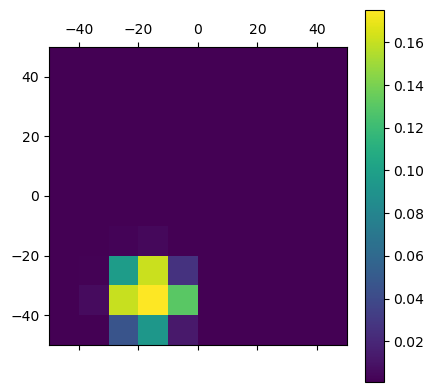

In [33]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 50
center_zero = [0,40,-20,-10,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-22 19:25:17,226 - INFO - z0: ((0, 0), 0.000875)
100%|██████████| 100/100 [01:02<00:00,  1.61it/s]
2025-10-22 19:26:19,312 - INFO - going home


0.192875
0.000875


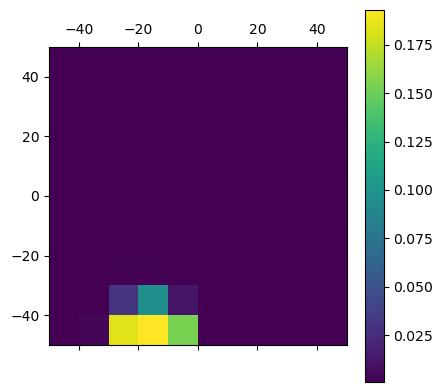

In [ ]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 50
center_zero = [0,-70,-20,160,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-22 19:34:15,314 - INFO - z0: ((0, 0), 0.000875)
100%|██████████| 100/100 [01:01<00:00,  1.62it/s]
2025-10-22 19:35:17,165 - INFO - going home


0.1625625
0.000875


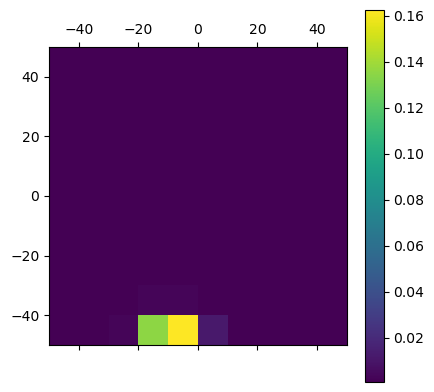

In [21]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 50
center_zero = [-10,-120,-20,247,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-23 15:54:50,091 - INFO - z0: ((0, 0), 0.000875)
100%|██████████| 100/100 [01:01<00:00,  1.62it/s]
2025-10-23 15:55:51,740 - INFO - going home


0.144125
0.000875


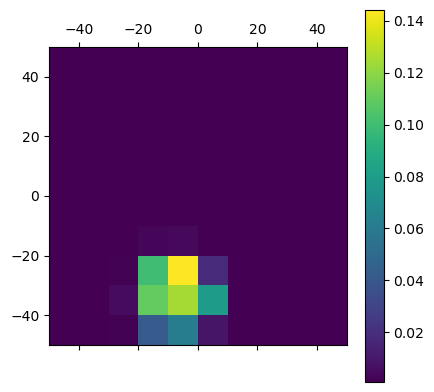

In [31]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 50
center_zero = [-10,110,-20,-102,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-23 12:07:04,252 - INFO - z0: ((0, 0), 0.000875)
100%|██████████| 100/100 [01:17<00:00,  1.29it/s]
2025-10-23 12:08:21,967 - INFO - going home


0.0023125
0.000875


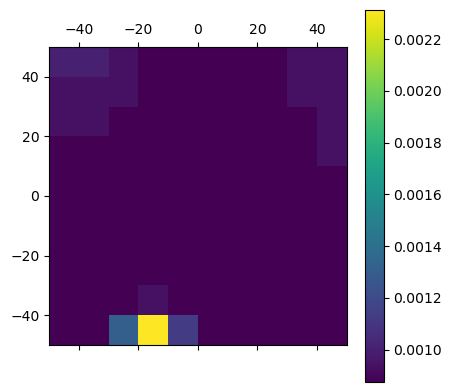

In [23]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 50
center_zero = [0,250,-20,-240,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-23 12:15:18,602 - INFO - z0: ((0, 0), 0.000875)
100%|██████████| 100/100 [01:17<00:00,  1.29it/s]
2025-10-23 12:16:36,199 - INFO - going home


0.001
0.000875


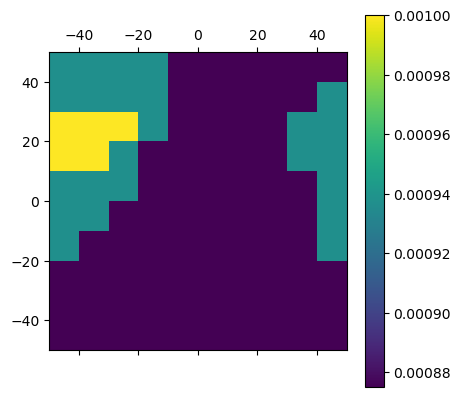

In [24]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 50
center_zero = [0,400,-20,-428,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-23 13:29:52,583 - INFO - z0: ((0, 0), 0.18325)
100%|██████████| 100/100 [01:01<00:00,  1.64it/s]
2025-10-23 13:30:53,620 - INFO - going home


0.19893750000000002
0.000875


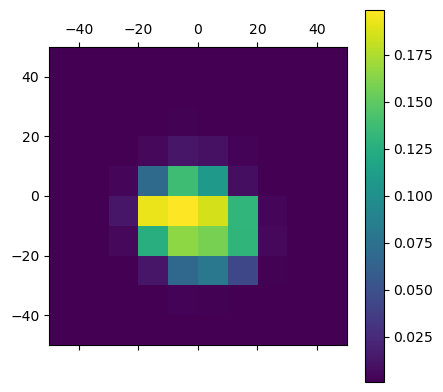

In [29]:
N_pts = 10
POS_MASK = A_XDOT_YDOT_MASK
SCAN_RANGE = 50
center_zero = [-20,10,-20,-10,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-23 17:29:19,083 - INFO - z0: ((0, 0), 0.1174375)
100%|██████████| 100/100 [01:04<00:00,  1.56it/s]
2025-10-23 17:30:23,216 - INFO - going home


0.12612500000000001
0.000875


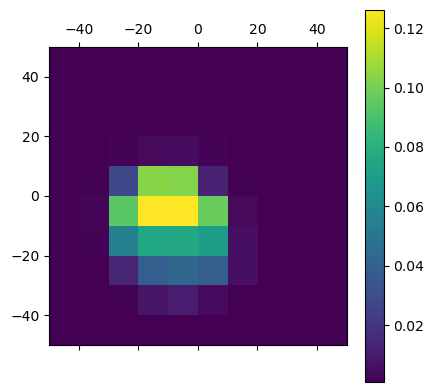

In [35]:
N_pts = 10
POS_MASK = A_XDOT_YDOT_MASK
SCAN_RANGE = 50
center_zero = [-25,120,-20,-150,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-24 13:50:36,302 - INFO - z0: ((0, 0), 0.0741875)
100%|██████████| 100/100 [01:03<00:00,  1.58it/s]
2025-10-24 13:51:39,428 - INFO - going home


0.1340625
0.000875


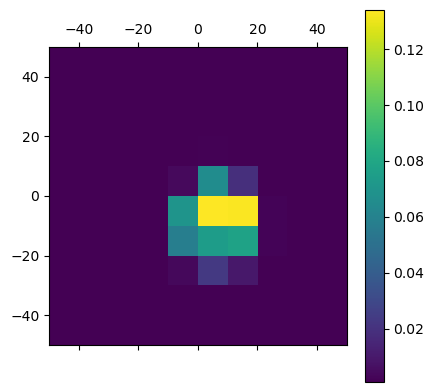

In [41]:
N_pts = 10
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 50
center_zero = [-25,120,-20,-150,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-23 17:37:12,347 - INFO - z0: ((0, 0), 0.026625)
100%|██████████| 100/100 [01:07<00:00,  1.48it/s]
2025-10-23 17:38:19,897 - INFO - going home


0.1203125
0.000875


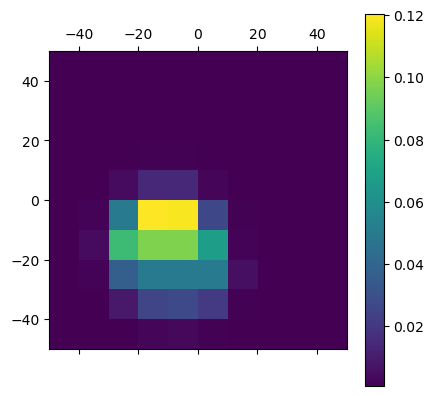

In [36]:
N_pts = 10
POS_MASK = A_XDOT_YDOT_MASK
SCAN_RANGE = 50
center_zero = [-25,140,-20,-170,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-24 13:42:35,311 - INFO - z0: ((0, 0), 0.03225)
100%|██████████| 100/100 [01:09<00:00,  1.44it/s]
2025-10-24 13:43:44,579 - INFO - going home


0.1278125
0.000875


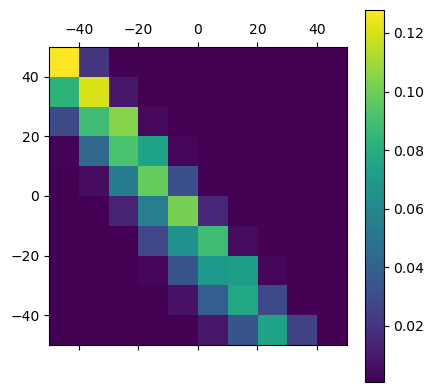

In [40]:
N_pts = 10
POS_MASK = A_Y_YDOT_MASK
SCAN_RANGE = 50
center_zero = [-25,140,-20,-170,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-24 13:18:39,443 - INFO - z0: ((0, 0), 0.001375)
100%|██████████| 625/625 [05:33<00:00,  1.88it/s]
2025-10-24 13:24:12,616 - INFO - going home


0.1953125
0.000875


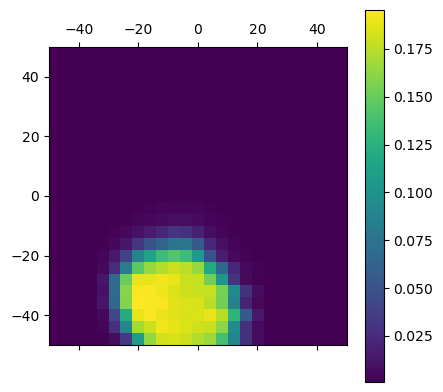

In [38]:
N_pts = 25
POS_MASK = A_XDOT_YDOT_MASK
SCAN_RANGE = 50
center_zero = [-25,-120,-20,200,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-24 13:53:11,425 - INFO - z0: ((0, 0), 0.00125)
100%|██████████| 625/625 [05:38<00:00,  1.85it/s]
2025-10-24 13:58:50,155 - INFO - going home


0.1915
0.000875


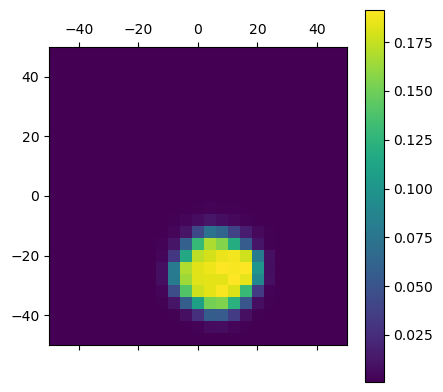

In [42]:
N_pts = 25
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 50
center_zero = [-25,-120,-20,200,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-24 13:25:54,732 - INFO - z0: ((0, 0), 0.0010625)
100%|██████████| 625/625 [05:34<00:00,  1.87it/s]
2025-10-24 13:31:29,135 - INFO - going home


0.1980625
0.000875


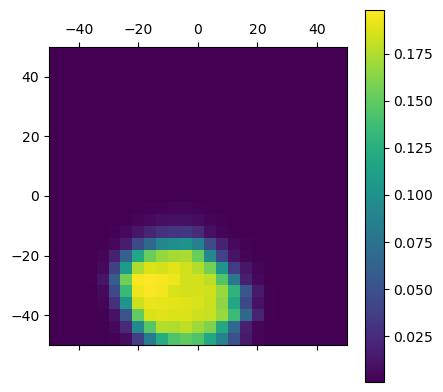

In [39]:
N_pts = 25
POS_MASK = A_XDOT_YDOT_MASK
SCAN_RANGE = 50
center_zero = [-25,-170,-20,270,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2025-10-24 13:59:03,731 - INFO - z0: ((0, 0), 0.0011250000000000001)
100%|██████████| 625/625 [06:31<00:00,  1.60it/s]
2025-10-24 14:05:35,575 - INFO - going home


0.19575
0.000875


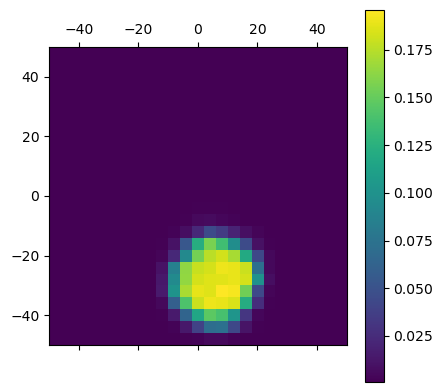

In [43]:
N_pts = 25
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 50
center_zero = [-25,-170,-20,270,0,0,0,0]
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=center_zero)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf, accept_func = posmask2acceptfunc(POS_MASK))
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

In [25]:
servos.set_angle([-40,420,-20,-428,0,0,0,0])

In [83]:
# print(servos.get_angle())
MCP3424_fiber.convert_and_read()/2*840

11.4975

Initial guess for p0:  [-3.00922690e+00  5.77563567e-01  9.29612179e+01  1.42011049e+01
  9.90031524e+01  9.72812500e-02  1.00000000e-01]
[-3.07223615  0.50888433] [[247.73961826  53.99331365]
 [ 53.99331365 259.5863138 ]]


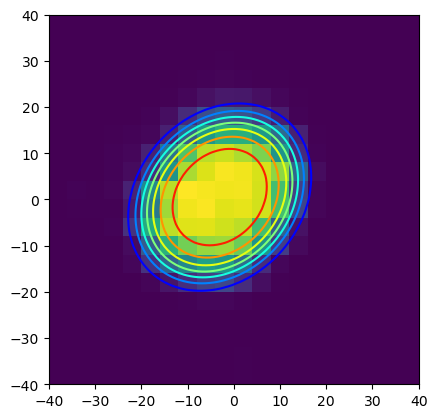

In [9]:
popt = fit_and_plot_smooth_heaviside(X1,Y1,Z1)
mu,cov = popt_get_mu_cov(popt)
print(mu, cov)

2025-07-23 17:38:14,554 - INFO - z0: ((0, 0), 0.2613125)
100%|██████████| 225/225 [02:00<00:00,  1.87it/s]
2025-07-23 17:40:15,025 - INFO - going home


0.2656875
0.0139375


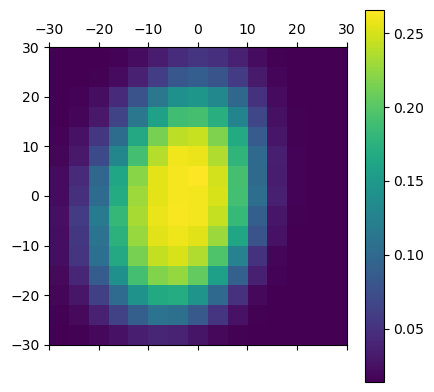

In [16]:
N_pts = 15
POS_MASK = B_X_Y_MASK
SCAN_RANGE = 30
cf = lambda para: callback_func(para,pos_mask=POS_MASK)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

Initial guess for p0:  [-3.68458035e+00 -5.66449180e-01  1.35521609e+02  1.93650530e+01
  2.06515042e+02  1.32843750e-01  1.00000000e-01]
[-4.20689457 -0.85479493]


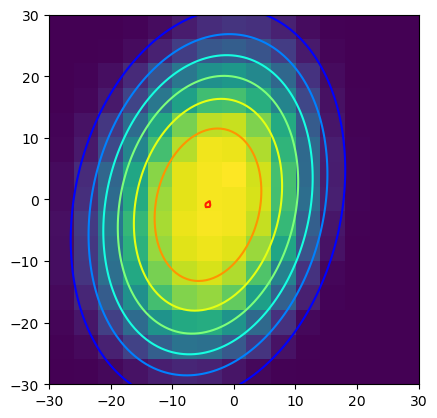

In [17]:
popt = fit_and_plot_smooth_heaviside(X1,Y1,Z1)
mu,cov = popt_get_mu_cov(popt)
print(mu)

In [ ]:
# jac_x0_pm11_rand11 = np.load("/home/rydpiservo/servodata/servosetup5/jac_pm11+rand11.npz",allow_pickle=True)
# jac_pm11_rand11 = jac_x0_pm11_rand11['jac']
# print(jac_pm11_rand11)
jac_x0_rand11 = np.load("/home/rydpiservo/servodata/servosetup5/jac_rand_11.npz",allow_pickle=True)
jac_rand11 = jac_x0_rand11['jac']
print(jac_rand11)
# jac_x0_pm11_rand11_lin20 = np.load("/home/rydpiservo/servodata/servosetup5/jac_pm11+rand11+lin20.npz",allow_pickle=True)
# jac_pm11_rand11_lin20 = jac_x0_pm11_rand11_lin20['jac']

[[-1.71856893 -0.83411755 -2.49782531 -1.08938854]
 [ 0.3964951  -1.51834118  1.04629983 -2.2908224 ]
 [-1.57183129 -1.11240104 -2.20998364 -1.40991615]
 [-0.24194203  1.33661006 -0.9286212   1.83550358]]


2025-01-15 13:54:56,230 - INFO - z0: ((0, 0), 0.1995)
100%|██████████| 225/225 [02:57<00:00,  1.27it/s]
2025-01-15 13:57:53,274 - INFO - going home


0.23018750000000002
0.0005


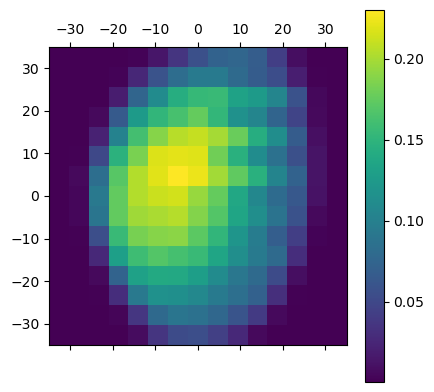

In [ ]:
N_pts = 15
POS_MASK = B_XDOT_YDOT_MASK #3x,4x
SCAN_RANGE = 35
cf = lambda para: callback_func(para,pos_mask=POS_MASK,jac=jac_rand11,jac_master_mask=B_POS_ALL_MASK)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)

2025-01-24 12:00:05,104 - INFO - z0: ((0, 0), 2.0479375)
100%|██████████| 225/225 [02:57<00:00,  1.27it/s]
2025-01-24 12:03:02,445 - INFO - going home


2.0479375
0.0004375


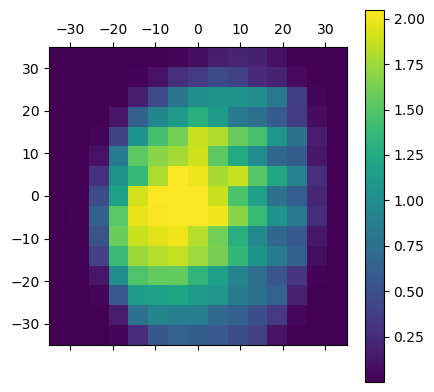

In [ ]:
N_pts = 15
POS_MASK = B_XDOT_YDOT_MASK #3x,4x
SCAN_RANGE = 35
cf = lambda para: callback_func(para,pos_mask=POS_MASK,jac=jac_rand11,jac_master_mask=B_POS_ALL_MASK)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)

2025-02-17 16:15:27,336 - INFO - z0: ((0, 0), 0.8245)
100%|██████████| 225/225 [02:56<00:00,  1.27it/s]
2025-02-17 16:18:24,129 - INFO - going home


0.901875
0.0004375


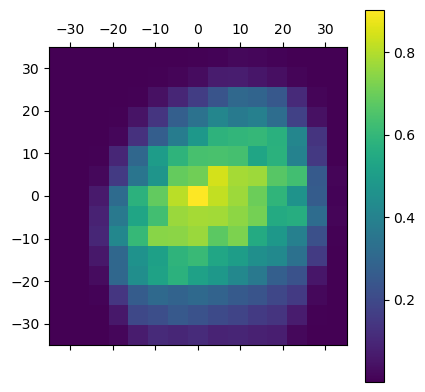

In [ ]:
N_pts = 15
POS_MASK = B_XDOT_YDOT_MASK #3x,4x
SCAN_RANGE = 35
cf = lambda para: callback_func(para,pos_mask=POS_MASK,jac=jac_rand11,jac_master_mask=B_POS_ALL_MASK)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)

2024-11-23 13:23:37,336 - INFO - z0: ((0, 0), 1.580125)
100%|██████████| 64/64 [00:52<00:00,  1.23it/s]
2024-11-23 13:24:29,396 - INFO - going home


1.6751875
0.0006875


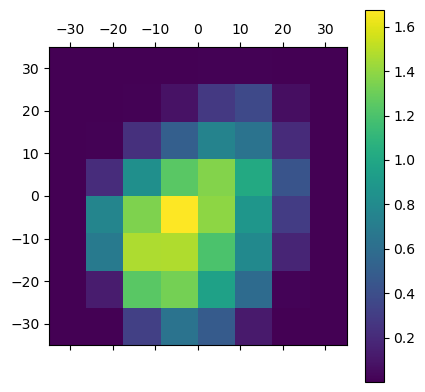

In [ ]:
N_pts = 8
POS_MASK = B_XDOT_YDOT_MASK
SCAN_RANGE = 35
cf = lambda para: callback_func(para,pos_mask=POS_MASK,jac=jac_pm11_rand11,jac_master_mask=B_POS_ALL_MASK)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)

2025-07-14 16:36:54,126 - INFO - z0: ((0, 0), 0.0764375)
100%|██████████| 100/100 [01:01<00:00,  1.64it/s]
2025-07-14 16:37:55,173 - INFO - going home


0.09925
0.0004375


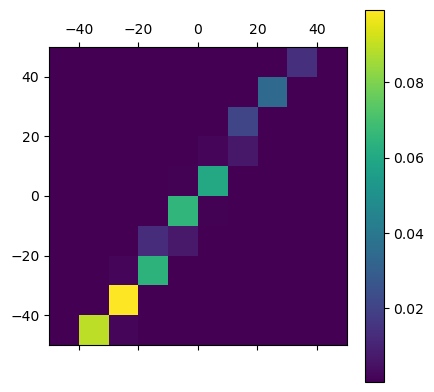

In [ ]:
N_pts = 10
POS_MASK = A_X_XDOT_MASK
SCAN_RANGE = 50
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=[0]*8)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)

In [ ]:
servos.torques_enable()

In [ ]:
# servos.get_angle()
servos.set_zero()

2025-07-14 16:51:01,318 - INFO - Setting Zero
2025-07-14 16:51:01,331 - INFO - Servo 1x: SCServo zero set!
2025-07-14 16:51:01,342 - INFO - Servo 1y: SCServo zero set!
2025-07-14 16:51:01,353 - INFO - Servo 2x: SCServo zero set!
2025-07-14 16:51:01,363 - INFO - Servo 2y: SCServo zero set!
2025-07-14 16:51:01,373 - INFO - Servo 3x: SCServo zero set!
2025-07-14 16:51:01,383 - INFO - Servo 3y: SCServo zero set!
2025-07-14 16:51:01,393 - INFO - Servo 4x: SCServo zero set!
2025-07-14 16:51:01,403 - INFO - Servo 4y: SCServo zero set!


In [ ]:
servos.set_angle([16.956733719056132, -26.4104054566061, 40.512469562534534, -11.293673892472839, 143.571, -395.7, -86.14, 258.429])
servos.torques_disable()

2025-07-14 17:11:03,466 - INFO - z0: ((0, 0), 0.3439375)
100%|██████████| 225/225 [02:03<00:00,  1.81it/s]
2025-07-14 17:13:07,454 - INFO - going home


0.349375
0.0005


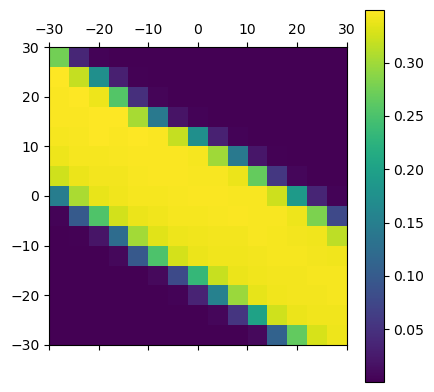

In [ ]:
N_pts = 15
POS_MASK = B_X_XDOT_MASK
SCAN_RANGE = 30
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=[0]*8)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)

2025-07-14 17:11:03,466 - INFO - z0: ((0, 0), 0.3439375)
100%|██████████| 225/225 [02:03<00:00,  1.81it/s]
2025-07-14 17:13:07,454 - INFO - going home


0.349375
0.0005


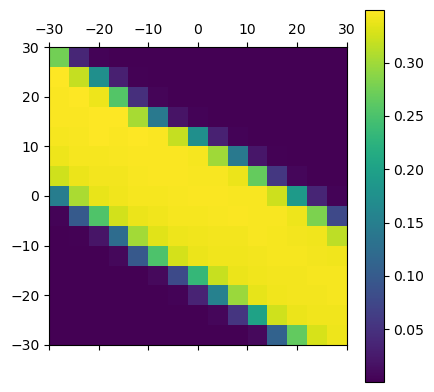

In [ ]:
N_pts = 25
POS_MASK = B_X_Y_MASK
SCAN_RANGE = 50
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=[0]*8)
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)

Initial guess for p0:  [-8.74615678e+00 -7.53117439e+00  8.18215871e+01  1.94952887e+01
  1.53895455e+02  1.73000000e-01  1.00000000e-01]
[-8.87833273 -8.01181009]


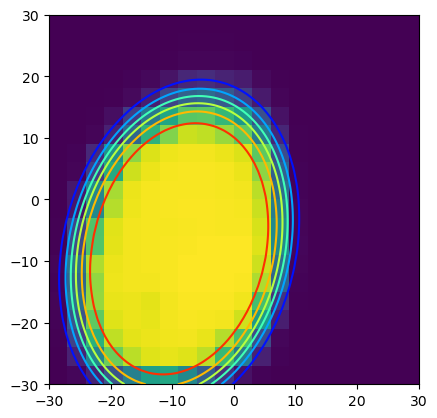

In [ ]:
popt = fit_and_plot_smooth_heaviside(X1,Y1,Z1)
mu,cov = popt_get_mu_cov(popt)
print(mu)

In [ ]:
servos.set_zero()

2025-07-14 17:23:48,582 - INFO - Setting Zero
2025-07-14 17:23:48,594 - INFO - Servo 1x: SCServo zero set!
2025-07-14 17:23:48,605 - INFO - Servo 1y: SCServo zero set!
2025-07-14 17:23:48,614 - INFO - Servo 2x: SCServo zero set!
2025-07-14 17:23:48,625 - INFO - Servo 2y: SCServo zero set!
2025-07-14 17:23:48,635 - INFO - Servo 3x: SCServo zero set!
2025-07-14 17:23:48,645 - INFO - Servo 3y: SCServo zero set!
2025-07-14 17:23:48,654 - INFO - Servo 4x: SCServo zero set!
2025-07-14 17:23:48,663 - INFO - Servo 4y: SCServo zero set!


In [ ]:
servos.get_angle()
# MCP3424_fiber.convert_and_read()

array([ -9.31640625,   1.58203125, -20.65429688,  -0.08789062,
         0.        ,   0.        ,   0.        ,   0.        ])

2025-07-09 18:31:45,010 - INFO - z0: ((0, 0), 0.3451875)
100%|██████████| 400/400 [03:24<00:00,  1.96it/s]
2025-07-09 18:35:09,478 - INFO - going home


0.3535625
0.0005625000000000001


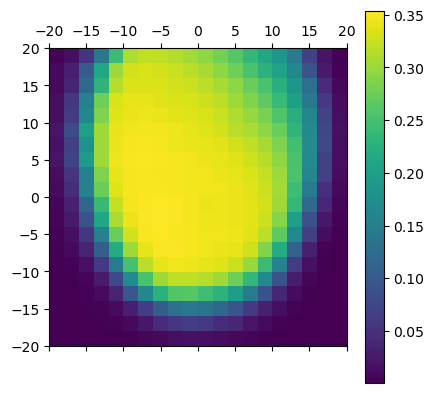

In [ ]:
N_pts = 20
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 20
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=[-36.63147269654397, -28.011103079581204, -51.38749529169222, 29.786121105173486, 15.0, 25.0, 0.0, 0.0])
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)

2025-07-10 15:14:30,375 - INFO - z0: ((0, 0), 0.3353125)
100%|██████████| 400/400 [03:28<00:00,  1.91it/s]
2025-07-10 15:17:59,349 - INFO - going home


0.3469375
0.0005625000000000001


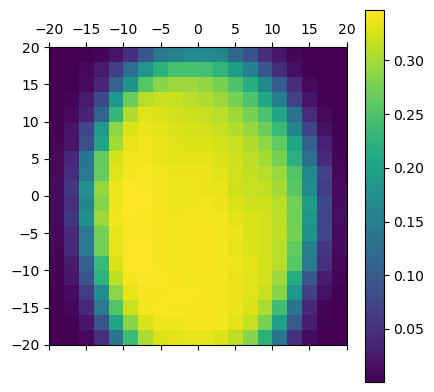

In [ ]:
N_pts = 20
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 20
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)

2025-07-09 19:06:36,831 - INFO - z0: ((0, 0), 0.3425625)
100%|██████████| 400/400 [03:55<00:00,  1.70it/s]
2025-07-09 19:10:32,337 - INFO - going home


0.35025
0.0005


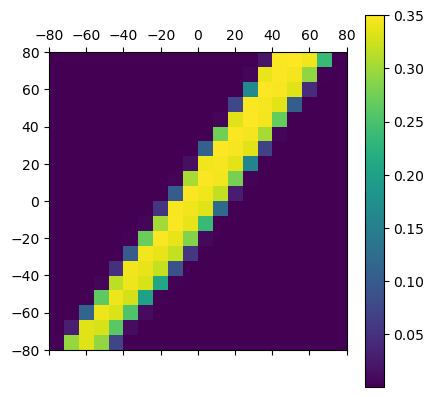

In [ ]:
N_pts = 20
POS_MASK = A_X_XDOT_MASK
SCAN_RANGE = 80
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=[-36.63147269654397, -28.011103079581204, -51.38749529169222, 29.786121105173486, 15.0, 25.0, 0.0, 0.0])
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)

2025-07-09 19:13:51,084 - INFO - z0: ((0, 0), 0.3424375)
100%|██████████| 400/400 [04:02<00:00,  1.65it/s]
2025-07-09 19:17:53,301 - INFO - going home


0.3459375
0.0005


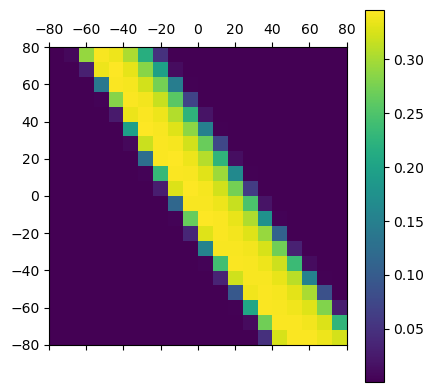

In [ ]:
N_pts = 20
POS_MASK = A_Y_YDOT_MASK
SCAN_RANGE = 80
cf = lambda para: callback_func(para,pos_mask=POS_MASK, zero=[-36.63147269654397, -28.011103079581204, -51.38749529169222, 29.786121105173486, 15.0, 25.0, 0.0, 0.0])
# cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)

In [ ]:
# cf([20,10])
servos.get_angle()

array([ -2.98828125,  23.5546875 ,   4.21875   , -24.16992188,
         6.41601562, -13.53515625,   0.        ,   0.        ])

In [ ]:
servos.get_angle()

array([ -2.98828125,  23.5546875 ,   4.21875   , -24.16992188,
         6.41601562, -13.53515625,   0.        ,   0.        ])

In [27]:
servos.torques_disable()
# servos.torques_enable()
# servos.get_angle()

Initial guess for p0:  [-6.94140537e-01 -1.46615988e-01  7.84583605e+01 -3.91518883e+00
  1.64674496e+02  8.85968750e-01  1.00000000e-01]
[-0.67911422 -0.15318578]


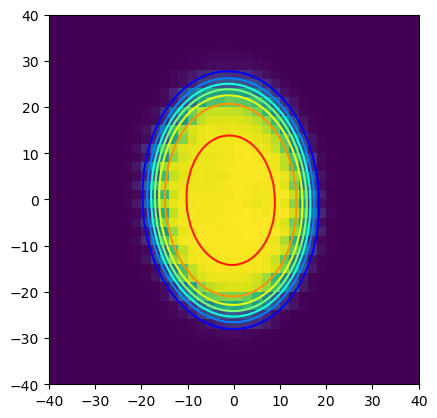

In [ ]:
popt = fit_and_plot_smooth_heaviside(X1,Y1,Z1)
mu,cov = popt_get_mu_cov(popt)
print(mu)

2024-10-24 18:30:24,064 - INFO - z0: ((0, 0), 0.4291875)
100%|██████████| 900/900 [04:37<00:00,  3.24it/s]
2024-10-24 18:35:01,450 - INFO - going home


0.5025000000000001
0.0005625000000000001


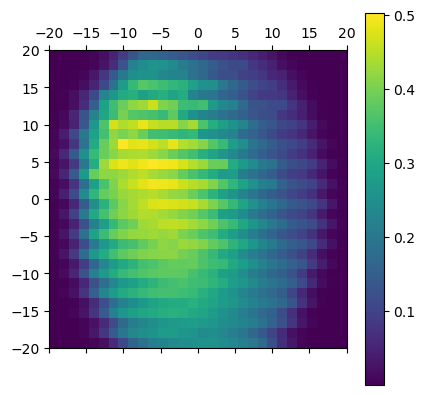

In [ ]:
N_pts = 30
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 20
cf = lambda para: callback_func(para,pos_mask=POS_MASK,jac=jac_pm10_rand10,jac_master_mask=A_POS_ALL_MASK,jac_x0 = jac_pm10_rand10_x0)
X2,Y2,Z2 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
np.savez("/home/rydpiservo/servodata/servosetup2/scan_AXY_pm10+rand10.npz",X2=X2,Y2=Y2,Z2=Z2)

2024-10-09 18:54:34,491 - INFO - z0: ((0, 0), 0.4435)
100%|██████████| 2500/2500 [14:58<00:00,  2.78it/s]
2024-10-09 19:09:33,215 - INFO - going home


0.49293750000000003
0.0005


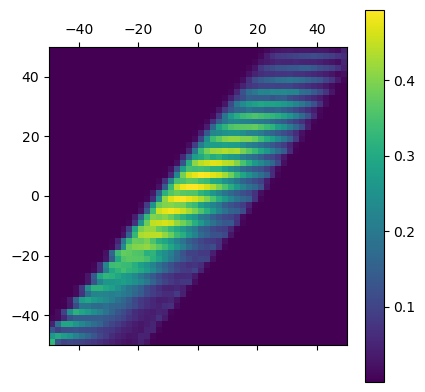

In [ ]:
N_pts = 50
POS_MASK = A_X_XDOT_MASK
SCAN_RANGE = 50
cf = lambda para: callback_func(para,pos_mask=POS_MASK,jac=jac_pm_10+lin70,jac_master_mask=A_POS_ALL_MASK,jac_x0 = jac_pm_10)
X2,Y2,Z2 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)

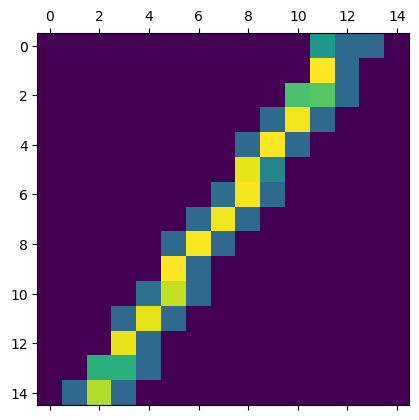

In [ ]:
Z_acc = accept_func_AYYDOT([X,Y])
plt.matshow(Z_acc*(0.3)+Z)

In [ ]:
idxmax = np.argmax(Z)
idxi,idxj = np.unravel_index(idxmax,X.shape)
maxpos = [X[idxi,idxj],Y[idxi,idxj]]
print(cf(maxpos))

((-2.8571428571428577, -20.0), 2.0479375)


In [ ]:
servos.set_zero()

2025-06-04 16:38:38,995 - INFO - Setting Zero
2025-06-04 16:38:39,007 - INFO - Servo 1x: SCServo zero set!
2025-06-04 16:38:39,017 - INFO - Servo 1y: SCServo zero set!
2025-06-04 16:38:39,026 - INFO - Servo 2x: SCServo zero set!
2025-06-04 16:38:39,035 - INFO - Servo 2y: SCServo zero set!
2025-06-04 16:38:39,045 - INFO - Servo 3x: SCServo zero set!
2025-06-04 16:38:39,054 - INFO - Servo 3y: SCServo zero set!
2025-06-04 16:38:39,064 - INFO - Servo 4x: SCServo zero set!
2025-06-04 16:38:39,073 - INFO - Servo 4y: SCServo zero set!


2024-10-08 17:01:20,351 - INFO - z0: ((0, 0), 0.0011250000000000001)
100%|██████████| 50/50 [00:16<00:00,  2.98it/s]
2024-10-08 17:01:37,148 - INFO - going home
2024-10-08 17:01:39,347 - INFO - z0: ((0, 0), 1.0058125)
100%|██████████| 50/50 [00:15<00:00,  3.23it/s]
2024-10-08 17:01:54,821 - INFO - going home
2024-10-08 17:01:56,982 - INFO - z0: ((0, 0), 1.0484375)
100%|██████████| 50/50 [00:14<00:00,  3.36it/s]
2024-10-08 17:02:11,861 - INFO - going home
2024-10-08 17:02:13,547 - INFO - z0: ((0, 0), 1.0663125)
100%|██████████| 50/50 [00:15<00:00,  3.33it/s]
2024-10-08 17:02:28,579 - INFO - going home
2024-10-08 17:02:30,277 - INFO - z0: ((0, 0), 1.040125)
100%|██████████| 50/50 [00:15<00:00,  3.30it/s]
2024-10-08 17:02:45,450 - INFO - going home
2024-10-08 17:02:47,684 - INFO - z0: ((0, 0), 0.0022500000000000003)
100%|██████████| 50/50 [00:15<00:00,  3.14it/s]
2024-10-08 17:03:03,619 - INFO - going home
2024-10-08 17:03:05,849 - INFO - z0: ((0, 0), 0.0010625)
100%|██████████| 50/50 [00

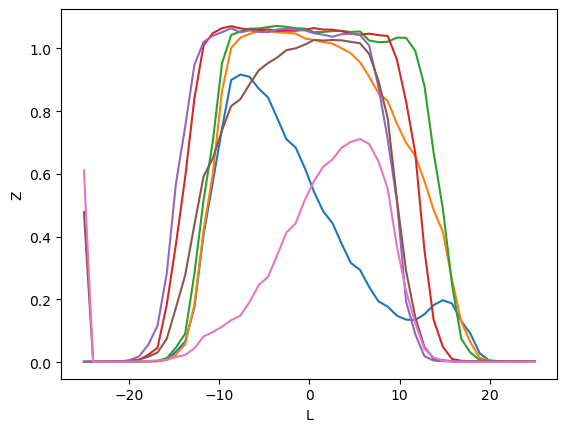

In [ ]:
N_pts = 50
POS_MASK = B_X_XDOT_MASK
SCAN_RANGE = 25
data=[]
for i in range(-3,4):
    zero = np.array([0,0,0,0,i*100,0,-67*i,0])
    cf = lambda para: callback_func(para,pos_mask=POS_MASK,zero=zero)
    vec = slope2perpvec(-0.67)
    L,Z = motor_1d_scan(N_pts,SCAN_RANGE,vec,servos,cf)
    data.append((i,L,Z))

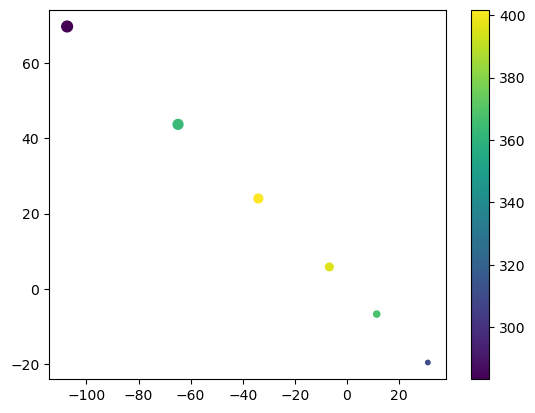

In [ ]:
import pickle
with open("/home/rydpiservo/servodata/servorecover2/xxdot_scan_when_moving_yydot.pkl","rb") as f:
    dataYoffset = pickle.load(f)

muList = []
sigmaList = []
for i in range(-2,4):
    for j in range(len(dataYoffset)):
        if dataYoffset[j][0] == i:
            mu,cov  = dataYoffset[j][1]
            # print(mu)
            muList.append(mu)
            eigval,eigvec = np.linalg.eig(cov)
            sigma = np.sqrt(eigval)
            sigmaList.append(sigma[0])

xList=[mu[0] for mu in muList]
yList=[mu[1] for mu in muList]
plt.scatter(xList,yList,s=np.arange(len(xList))*10+10,c=sigmaList)
plt.colorbar()

In [ ]:
i=1
zero = np.array([0,0,0,0,0,100*i,0,-67*i])
zero[4]=-33.99
zero[6]=23.99
print(zero)

[  0   0   0   0 -33 100  23 -67]


2024-10-08 17:57:40,633 - INFO - z0: ((0, 0), 0.0011875)
100%|██████████| 50/50 [00:16<00:00,  3.10it/s]
2024-10-08 17:57:56,777 - INFO - going home
2024-10-08 17:57:59,014 - INFO - z0: ((0, 0), 0.5298125)
100%|██████████| 50/50 [00:15<00:00,  3.33it/s]
2024-10-08 17:58:14,025 - INFO - going home
2024-10-08 17:58:16,253 - INFO - z0: ((0, 0), 0.8908125)
100%|██████████| 50/50 [00:14<00:00,  3.39it/s]
2024-10-08 17:58:31,022 - INFO - going home
2024-10-08 17:58:33,246 - INFO - z0: ((0, 0), 0.9359375)
100%|██████████| 50/50 [00:14<00:00,  3.41it/s]
2024-10-08 17:58:47,912 - INFO - going home
2024-10-08 17:58:50,140 - INFO - z0: ((0, 0), 0.0015)
100%|██████████| 50/50 [00:15<00:00,  3.33it/s]
2024-10-08 17:59:05,147 - INFO - going home
2024-10-08 17:59:07,374 - INFO - z0: ((0, 0), 0.0011250000000000001)
100%|██████████| 50/50 [00:16<00:00,  3.12it/s]
2024-10-08 17:59:23,397 - INFO - going home
2024-10-08 17:59:25,624 - INFO - z0: ((0, 0), 0.0009375)
100%|██████████| 50/50 [00:16<00:00,  3.

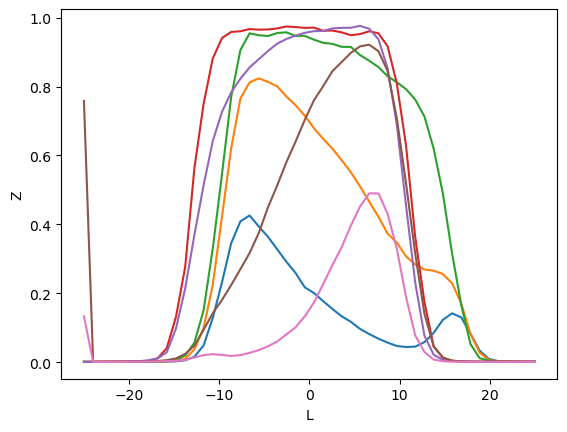

In [ ]:
N_pts = 50
POS_MASK = B_X_XDOT_MASK
SCAN_RANGE = 25
dataXoffset=[]
idx=0
xxdot =muList[0]
yydot = np.array([100*(-2+idx),(-67)*(-2+idx)])
# for i in range(-3,4):
#     zero = np.array([0,0,0,0,xxdot[0]+ i*100, yydot[0],xxdot[1]+i*(-67),yydot[1]])
#     cf = lambda para: callback_func(para,pos_mask=POS_MASK,zero=zero)
#     vec = slope2perpvec(-0.67)
#     L,Z = motor_1d_scan(N_pts,SCAN_RANGE,vec,servos,cf)
#     dataXoffset.append((i,L,Z))

In [ ]:
with open("/home/rydpiservo/servodata/servorecover2/xxdot_1dscan_at_yydot=mu[0].pkl","wb") as f:
    pickle.dump(dataXoffset,f)

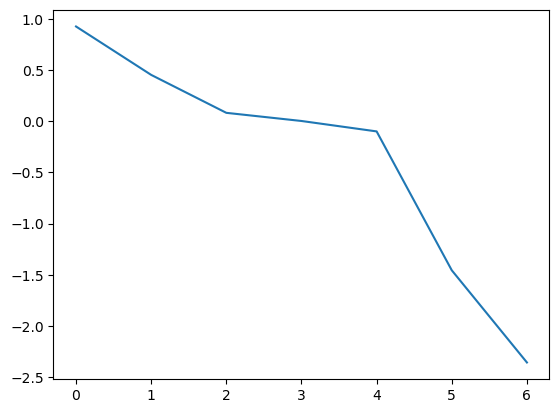

In [ ]:
LList = [L for i,L,Z in dataXoffset]
ZList = [Z for i,L,Z in dataXoffset]
skewnesList = [statistics_skewness(L,Z) for L,Z in zip(LList,ZList)]
plt.plot(skewnesList)

2024-10-07 17:19:38,776 - INFO - z0: ((0, 0), 1.0434375)
100%|██████████| 1600/1600 [02:40<00:00,  9.98it/s]
2024-10-07 17:22:19,072 - INFO - going home


1.0469375
0.0


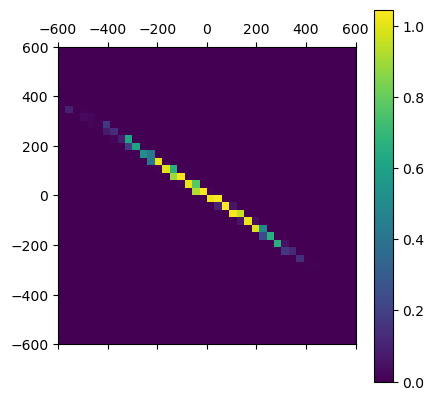

In [ ]:
# N_pts = 100
N_pts = 40
POS_MASK = B_X_XDOT_MASK
# SCAN_RANGE = 500 if POS_MASK==B_X_XDOT_MASK else 800
SCAN_RANGE = 600 if POS_MASK==B_X_XDOT_MASK else 800
cf = lambda para: callback_func(para,pos_mask=POS_MASK)
scan_start_time = time.time()
# X,Y,Z = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
X,Y,Z = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf,accept_func=posmask2acceptfunc(POS_MASK))
scan_stop_time = time.time()
posmaskstr = posmask2str(POS_MASK)
fileName="clip_{}_{}".format(posmaskstr,ITER_NUM)
# np.savez("/home/rydpiservo/servodata/servorecover/{}_re_large.npz".format(fileName),X=X,Y=Y,Z=Z,posmask = POS_MASK,posmaskstr = posmaskstr,ITER_NUM=ITER_NUM,scan_start_time=scan_start_time,scan_stop_time=scan_stop_time)

Initial guess for p0:  [-1.21959840e+00 -6.02702012e+00  3.97677009e+04 -2.65656531e+04
  1.78664619e+04  1.00000000e-01]


/home/rydpiservo/expctl/src/expctl/servers/servoaligner/fit_gaussian.py:21: RuntimeWarning: overflow encountered in exp
  smooth_transition = 1 / (1 + np.exp((quadratic_form - 1) / transition_width))


[-6.35724952e-01 -6.30042667e+00  1.40510622e+05 -9.40867544e+04
  6.33826458e+04  1.97106768e-01]
[451.25376272  16.22680028]


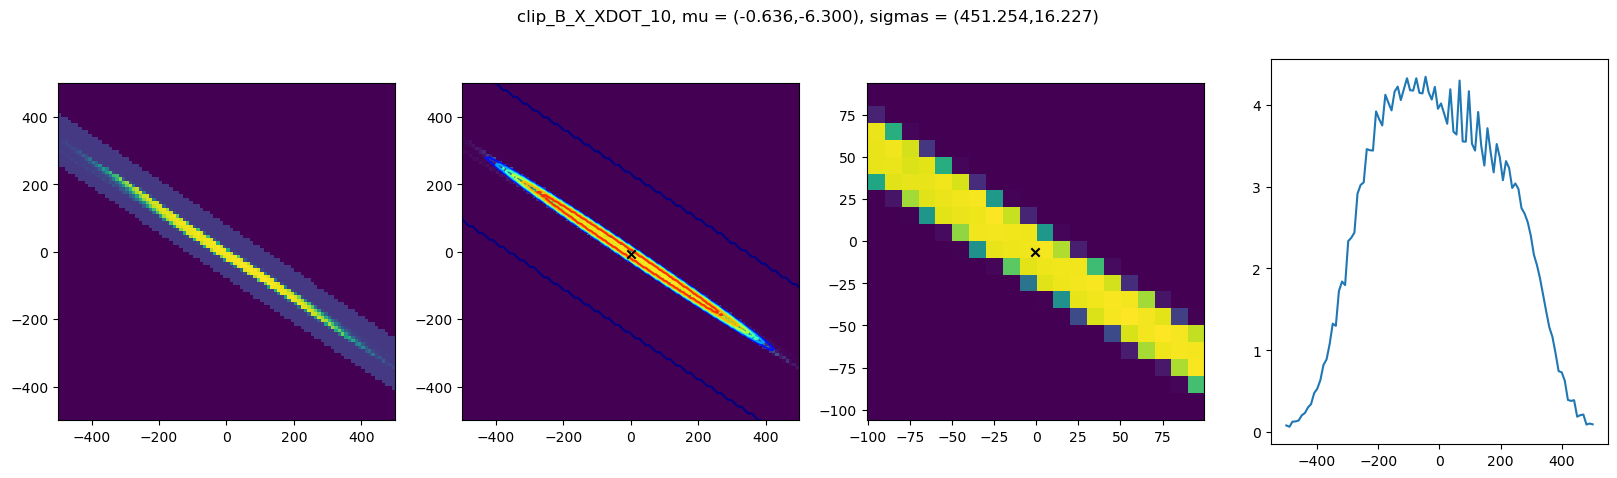

In [ ]:
fig,ax = plt.subplots(1,4,figsize=(20,5))
Z_norm = Z/np.max(Z)

# ax0. accept_func
ax0 = ax[0]
Zacc = np.zeros_like(X)
if isinstance(N_pts,int):
    N_pts_x,N_pts_y = N_pts,N_pts
elif isinstance(N_pts,tuple):
    N_pts_x,N_pts_y = N_pts

accept_func = posmask2acceptfunc(POS_MASK)
xy = np.array([X, Y])  # Combine X and Y arrays
Zacc = accept_func(xy).astype(int)  # Apply the acceptance function and convert to int
ax0.imshow(Zacc*0.2+Z_norm, extent=[X.min(), X.max(), Y.min(), Y.max()],origin='lower')

# ax1. fit_gaussian_2d
ax1 = ax[1]
popt=fit_and_plot_smooth_heaviside(X,Y,Z,ax=ax1)
mu,cov = popt_get_mu_cov(popt)
ax1.scatter(mu[0],mu[1],marker='x',color='black',zorder=10)
eigvals, eigvecs = np.linalg.eig(cov)
sigmas= np.sqrt(eigvals)
print(popt)
print(sigmas)
np.savez("/home/rydpiservo/servodata/servorecover/{}_popt.npz".format(fileName),popt=popt,mu=mu,cov=cov,sigmas=sigmas)

# ax2. central point magnify
ax2 = ax[2]
ax2.imshow(Z_norm, extent=[X.min(), X.max(), Y.min(), Y.max()],origin='lower')
ax2.scatter(mu[0],mu[1],marker='x',color='black')
ax2.set_xlim([mu[0]-100,mu[0]+100])
ax2.set_ylim([mu[1]-100,mu[1]+100])

# ax3, row sum
ax3 = ax[3]
Z_row = np.sum(Z,axis=0)
ax3.plot(X[0,:],Z_row)
#
# suptitle
fig.suptitle("{}, mu = ({:.3f},{:.3f}), sigmas = ({:.3f},{:.3f})".format(fileName,mu[0],mu[1],sigmas[0],sigmas[1]))
plt.savefig("/home/rydpiservo/servodata/servorecover/{}.png".format(fileName),dpi=300,bbox_inches='tight')


In [ ]:
cf(list(mu))
time.sleep(1)
logging.info("going to mu: {}".format(mu))
_,I = cf(list(mu))
logging.info("I: {}".format(I))
if I>0.3:
    logging.info("setting zero point")
    # servos.set_zero()
else:
    logging.info("I too small, not setting zero point")
time.sleep(1)


2024-10-05 20:46:54,185 - INFO - going to mu: [-0.63572495 -6.30042667]
2024-10-05 20:46:54,415 - INFO - I: 1.106875
2024-10-05 20:46:54,418 - INFO - setting zero point


## Iterative Spiral Optimization

In [ ]:
zero = np.array([0,0,0,0,0,0,0,0],dtype=float)
offset = np.array([0,0,0,0],dtype=float)

2024-10-02 17:17:58,664 - INFO - Offset = [0. 0. 0. 0.], Zero = [ 0.          0.          0.          0.         10.18064443  1.12136333
 -7.22576165 -1.44739995]
2024-10-02 17:17:58,667 - INFO - Start optimization with zero = [ 0.          0.          0.          0.         10.18064443  1.12136333
 -7.22576165 -1.44739995]
2024-10-02 17:17:58,844 - INFO - Start position: x_0=0.00 x_1=0.00 x_2=0.00 x_3=0.00, start I: 0.404625


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -3.97188D-01    |proj g|=  6.58875D-02

At iterate    1    f= -4.00313D-01    |proj g|=  5.69875D-02

At iterate    2    f= -4.09938D-01    |proj g|=  6.02250D-02
  ys=-6.987E-05  -gs= 7.989E-04 BFGS update SKIPPED


2024-10-02 17:18:23,497 - INFO - Converged position: x_0=-0.03 x_1=-0.00 x_2=-0.07 x_3=-0.04
2024-10-02 17:18:23,498 - INFO - Best point: x_0=-0.06 x_1=5.00 x_2=-0.19 x_3=-0.16; T=0.42262500000000003



At iterate    3    f= -4.08250D-01    |proj g|=  6.06750D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    4      3     14      3     1     0   6.067D-02  -4.083D-01
  F = -0.40825000000000000     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             


2024-10-02 17:18:23,875 - INFO - Best position: x_0=-0.06 x_1=5.00 x_2=-0.19 x_3=-0.16, now I: 0.38175000000000003
2024-10-02 17:18:23,876 - INFO - New Origin set to be x_0=-0.06 x_1=5.00 x_2=-0.19 x_3=-0.16
2024-10-02 17:18:23,877 - INFO - Zero = [ 0.          0.          0.          0.         10.12463103  6.11854646
 -7.42008895 -1.60549327]


0.4003125


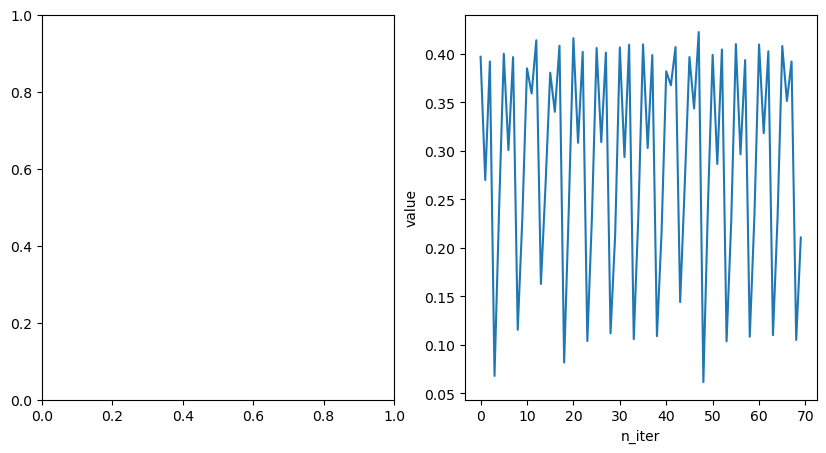

In [ ]:
offset_mask = A_POS_ALL_MASK
logging.info(f"Offset = {offset}, Zero = {zero}")
#
#
try:
    logging.info(f"Start optimization with zero = {zero}")
    # zero = step_optimize(servos,callback_func,pos_mask = B_X_Y_MASK,zero=zero,bounds_single = (-100,100))
    # zero = step_optimize(servos,callback_func,pos_mask = B_X_XDOT_MASK,zero=zero)
    # zero = step_optimize(servos,callback_func,pos_mask = B_Y_YDOT_MASK,zero=zero)
    zero = step_optimize(servos,callback_func,pos_mask = B_POS_ALL_MASK,zero=zero,method='L-BFGS-B')
    #
    _,I = callback_func(zero,pos_mask=POS_ALL_MASK)
    print(I)
    #
    # dataset[tuple(offset)].append((list(zero),I))
    # print(dataset)
    # np.save(filename,dataset)
    # print("i=",i)

except Exception as e:
    servos.close()
    logging.error(f"Error in iterative_optimize: {e}")